In [ ]:
# ============================================
# VOLTRELAY ENERGY - DATA ANALYTICS HACKATHON
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving batteries.csv to batteries (1).csv
Saving city_daily_context.csv to city_daily_context (1).csv
Saving fleet_partners.csv to fleet_partners (1).csv
Saving riders.csv to riders.csv
Saving station_hourly_status.csv to station_hourly_status.csv
Saving stations.csv to stations.csv
Saving support_tickets.csv to support_tickets.csv
Saving swap_events.zip to swap_events.zip


In [ ]:
import zipfile
import os

zip_path = "/content/swap_events.zip"
extract_path = "/content/swap_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Extraction completed!
/content/swap_data/swap_events.csv


In [ ]:
import os

print("Files in Colab:\n")

for file in os.listdir("/content"):
    print(file)

Files in Colab:

.config
swap_data
fleet_partners.csv
support_tickets.csv
city_daily_context.csv
drive
station_hourly_status.csv
city_daily_context (1).csv
swap_events.zip
stations.csv
fleet_partners (1).csv
batteries.csv
riders.csv
batteries (1).csv
sample_data


In [ ]:
import os

print("REQUIRED DATASETS")
print("=" * 50)

required = [
    "/content/batteries.csv",
    "/content/city_daily_context.csv",
    "/content/fleet_partners.csv",
    "/content/riders.csv",
    "/content/station_hourly_status.csv",
    "/content/stations.csv",
    "/content/support_tickets.csv",
    "/content/swap_data/swap_events.csv"
]

for path in required:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {path}  ({size_mb:.1f} MB)")
    else:
        print(f"✗ MISSING: {path}")

REQUIRED DATASETS
✓ /content/batteries.csv  (0.6 MB)
✓ /content/city_daily_context.csv  (0.2 MB)
✓ /content/fleet_partners.csv  (0.0 MB)
✓ /content/riders.csv  (2.0 MB)
✓ /content/station_hourly_status.csv  (103.3 MB)
✓ /content/stations.csv  (0.0 MB)
✓ /content/support_tickets.csv  (6.2 MB)
✓ /content/swap_data/swap_events.csv  (695.0 MB)


In [ ]:
import pandas as pd

DATA_PATH = "/content/"

riders = pd.read_csv(DATA_PATH + "riders.csv")
batteries = pd.read_csv(DATA_PATH + "batteries.csv")
stations = pd.read_csv(DATA_PATH + "stations.csv")
support_tickets = pd.read_csv(DATA_PATH + "support_tickets.csv")
city_context = pd.read_csv(DATA_PATH + "city_daily_context.csv")
fleet_partners = pd.read_csv(DATA_PATH + "fleet_partners.csv")
station_hourly = pd.read_csv(DATA_PATH + "station_hourly_status.csv")

print("Smaller datasets loaded successfully!")

Smaller datasets loaded successfully!


In [ ]:
swap_file = "/content/swap_data/swap_events.csv"

chunks = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000
):
    chunks.append(chunk)

swap_events = pd.concat(
    chunks,
    ignore_index=True
)

print("Swap events loaded successfully!")
print("Shape:", swap_events.shape)

Swap events loaded successfully!
Shape: (3877013, 22)


In [ ]:
print("riders:", riders.shape)
print("batteries:", batteries.shape)
print("stations:", stations.shape)
print("station_hourly:", station_hourly.shape)
print("support_tickets:", support_tickets.shape)
print("city_context:", city_context.shape)
print("fleet_partners:", fleet_partners.shape)
print("swap_events:", swap_events.shape)

riders: (20000, 12)
batteries: (6500, 13)
stations: (152, 22)
station_hourly: (1487712, 14)
support_tickets: (44000, 12)
city_context: (3282, 12)
fleet_partners: (12, 12)
swap_events: (3877013, 22)


In [ ]:
import os

print("Files available:\n")

for file in os.listdir(DATA_PATH):
    print(file)

Files available:

.config
swap_data
fleet_partners.csv
support_tickets.csv
city_daily_context.csv
drive
station_hourly_status.csv
city_daily_context (1).csv
swap_events.zip
stations.csv
fleet_partners (1).csv
batteries.csv
riders.csv
batteries (1).csv
sample_data


In [ ]:
# ============================================
# LOAD SMALL / DIMENSION TABLES
# ============================================

riders = pd.read_csv(
    DATA_PATH + "riders.csv"
)

batteries = pd.read_csv(
    DATA_PATH + "batteries.csv"
)

stations = pd.read_csv(
    DATA_PATH + "stations.csv"
)

support_tickets = pd.read_csv(
    DATA_PATH + "support_tickets.csv"
)

city_context = pd.read_csv(
    DATA_PATH + "city_daily_context.csv"
)

fleet_partners = pd.read_csv(
    DATA_PATH + "fleet_partners.csv"
)

print("Riders:", riders.shape)
print("Batteries:", batteries.shape)
print("Stations:", stations.shape)
print("Support tickets:", support_tickets.shape)
print("City context:", city_context.shape)
print("Fleet partners:", fleet_partners.shape)

Riders: (20000, 12)
Batteries: (6500, 13)
Stations: (152, 22)
Support tickets: (44000, 12)
City context: (3282, 12)
Fleet partners: (12, 12)


In [ ]:
station_hourly = pd.read_csv(
    DATA_PATH + "station_hourly_status.csv"
)

print("Station hourly status:", station_hourly.shape)

Station hourly status: (1487712, 14)


In [ ]:
datasets = {
    "riders": riders,
    "batteries": batteries,
    "stations": stations,
    "support_tickets": support_tickets,
    "city_context": city_context,
    "fleet_partners": fleet_partners,
    "station_hourly": station_hourly
}

for name, df in datasets.items():
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print(df.columns.tolist())


RIDERS
Rows: 20000
Columns: 12
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

BATTERIES
Rows: 6500
Columns: 13
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'bms_firmware', 'retired_date', 'retirement_reason', 'current_soh_pct']

STATIONS
Rows: 152
Columns: 22
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

SUPPORT_TICKETS
Rows: 44000
Columns: 12
['ticket_id', 'rider_id', 'station_id',

In [ ]:
# ============================================
# LOAD LARGE SWAP EVENTS TABLE IN CHUNKS
# ============================================

swap_file = DATA_PATH + "swap_data/swap_events.csv"

chunks = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000
):
    chunks.append(chunk)

swap_events = pd.concat(chunks, ignore_index=True)

print("Swap events loaded successfully.")
print("Shape:", swap_events.shape)

Swap events loaded successfully.
Shape: (3877013, 22)


In [ ]:
swap_events.head()

,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.00,100.60,98.70,98.90,80.40,PARTNER,60.00,6.00,54.00,partner_invoice,2.04,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.30,98.30,97.30,98.20,66.10,PARTNER,60.00,9.00,51.00,partner_invoice,2.16,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.50,99.10,99.80,99.10,66.60,STD,60.00,0.00,60.00,partner_invoice,2.04,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.90,99.60,98.40,98.20,65.40,STD,60.00,0.00,60.00,partner_invoice,2.19,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.50,99.20,95.60,99.90,73.80,STD,60.00,0.00,60.00,partner_invoice,1.97,v3.2.1,realtime


In [ ]:
swap_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3877013 entries, 0 to 3877012
Data columns (total 22 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   event_id                object 
 1   rider_id                object 
 2   station_id              object 
 3   event_ts                object 
 4   event_type              object 
 5   attempt_seq             int64  
 6   queue_wait_sec          int64  
 7   battery_in_id           object 
 8   battery_out_id          object 
 9   soc_in_pct              float64
 10  soh_in_pct              float64
 11  soc_out_pct             float64
 12  soh_out_pct             float64
 13  km_since_last_swap      float64
 14  tariff_code             object 
 15  list_price_inr          float64
 16  discount_inr            float64
 17  amount_charged_inr      float64
 18  payment_mode            object 
 19  energy_to_recharge_kwh  float64
 20  station_firmware        object 
 21  sync_mode               object 

In [ ]:
swap_events.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,3877013,3877013,SW-003877013,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,3877013,19950,RD-1001634,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,3877013,152,STN-BLR-019,58067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,3877013,3585281,2025-06-10 19:31:47,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,3877013,5,swap_completed,3645809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attempt_seq,"3,877,013.00",NaN,NaN,NaN,1.00,0.00,1.00,1.00,1.00,1.00,1.00
queue_wait_sec,"3,877,013.00",NaN,NaN,NaN,242.95,163.91,0.00,137.00,206.00,305.00,"2,400.00"
battery_in_id,3848731,6500,BAT-2W-106267,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_out_id,3645809,6500,BAT-2W-104960,743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soc_in_pct,"3,848,731.00",NaN,NaN,NaN,9.29,4.45,1.00,6.00,9.30,12.50,28.40


In [ ]:
# ============================================
# DATETIME CONVERSION
# ============================================

swap_events["event_ts"] = pd.to_datetime(
    swap_events["event_ts"],
    errors="coerce"
)

riders["signup_date"] = pd.to_datetime(
    riders["signup_date"],
    errors="coerce"
)

stations["commissioned_date"] = pd.to_datetime(
    stations["commissioned_date"],
    errors="coerce"
)

stations["decommissioned_date"] = pd.to_datetime(
    stations["decommissioned_date"],
    errors="coerce"
)

batteries["manufacture_date"] = pd.to_datetime(
    batteries["manufacture_date"],
    errors="coerce"
)

batteries["commission_date"] = pd.to_datetime(
    batteries["commission_date"],
    errors="coerce"
)

batteries["retired_date"] = pd.to_datetime(
    batteries["retired_date"],
    errors="coerce"
)

support_tickets["created_ts"] = pd.to_datetime(
    support_tickets["created_ts"],
    errors="coerce"
)

city_context["date"] = pd.to_datetime(
    city_context["date"],
    errors="coerce"
)

station_hourly["hour_start"] = pd.to_datetime(
    station_hourly["hour_start"],
    errors="coerce"
)

fleet_partners["contract_start_date"] = pd.to_datetime(
    fleet_partners["contract_start_date"],
    errors="coerce"
)

fleet_partners["amendment_date"] = pd.to_datetime(
    fleet_partners["amendment_date"],
    errors="coerce"
)

print("Datetime conversion completed.")

Datetime conversion completed.


In [ ]:
# ============================================
# TIME FEATURES
# ============================================

swap_events["date"] = swap_events["event_ts"].dt.date
swap_events["month"] = swap_events["event_ts"].dt.to_period("M").astype(str)
swap_events["year"] = swap_events["event_ts"].dt.year
swap_events["month_num"] = swap_events["event_ts"].dt.month
swap_events["hour"] = swap_events["event_ts"].dt.hour
swap_events["day_of_week"] = swap_events["event_ts"].dt.day_name()
swap_events["is_weekend"] = (
    swap_events["event_ts"].dt.dayofweek >= 5
)

print(
    swap_events[
        ["event_ts", "date", "month", "year", "hour",
         "day_of_week", "is_weekend"]
    ].head()
)

             event_ts        date    month  year  hour day_of_week  is_weekend
0 2024-01-01 11:10:56  2024-01-01  2024-01  2024    11      Monday       False
1 2024-01-01 17:13:06  2024-01-01  2024-01  2024    17      Monday       False
2 2024-01-01 20:15:14  2024-01-01  2024-01  2024    20      Monday       False
3 2024-01-01 20:26:07  2024-01-01  2024-01  2024    20      Monday       False
4 2024-01-01 21:13:07  2024-01-01  2024-01  2024    21      Monday       False


In [ ]:
event_summary = (
    swap_events["event_type"]
    .value_counts()
    .to_frame("attempts")
)

event_summary["percentage"] = (
    event_summary["attempts"]
    / len(swap_events)
    * 100
)

event_summary

,attempts,percentage
event_type,,
swap_completed,3645809,94.04
failed_no_charged_battery,134389,3.47
abandoned_queue,68533,1.77
cancelled_by_rider,16712,0.43
failed_system_error,11570,0.30


In [ ]:
# ============================================
# EVENT OUTCOME FLAGS
# ============================================

swap_events["is_completed"] = (
    swap_events["event_type"] == "swap_completed"
)

swap_events["is_failed"] = (
    swap_events["event_type"] != "swap_completed"
)

swap_events["is_no_battery"] = (
    swap_events["event_type"] == "failed_no_charged_battery"
)

swap_events["is_abandoned"] = (
    swap_events["event_type"] == "abandoned_queue"
)

swap_events["is_cancelled"] = (
    swap_events["event_type"] == "cancelled_by_rider"
)

swap_events["is_system_error"] = (
    swap_events["event_type"] == "failed_system_error"
)

In [ ]:
test_station_mask = (
    swap_events["station_id"]
    .astype(str)
    .str.startswith("STN-TST")
)

print("Test-station events:", test_station_mask.sum())

swap_analysis = swap_events.loc[
    ~test_station_mask
].copy()

print("Rows after excluding test stations:", len(swap_analysis))

Test-station events: 62031
Rows after excluding test stations: 3814982


In [ ]:
# ============================================
# CLEAN RANGE / DISTANCE
# ============================================

swap_analysis["km_clean"] = swap_analysis["km_since_last_swap"]

invalid_km = (
    (swap_analysis["km_clean"] < 0) |
    (swap_analysis["km_clean"] > 500)
)

print("Invalid distance observations:", invalid_km.sum())

swap_analysis.loc[invalid_km, "km_clean"] = np.nan

Invalid distance observations: 7687


In [ ]:
# ============================================
# CLEAN SOH / SOC
# ============================================

for col in [
    "soh_in_pct",
    "soh_out_pct",
    "soc_in_pct",
    "soc_out_pct"
]:
    if col in swap_analysis.columns:
        swap_analysis.loc[
            (swap_analysis[col] < 0) |
            (swap_analysis[col] > 100),
            col
        ] = np.nan

In [ ]:
stations["city"].value_counts()

,count
city,
Bengaluru,34
Delhi NCR,30
Hyderabad,26
Pune,22
Mumbai,22
Jaipur,18


In [ ]:
station_city = stations[
    ["station_id", "city", "zone", "location_type",
     "charger_generation", "slots_2w", "slots_3w",
     "expansion_wave"]
].copy()

swap_analysis = swap_analysis.merge(
    station_city,
    on="station_id",
    how="left"
)

swap_analysis.rename(
    columns={"city": "station_city"},
    inplace=True
)

In [ ]:
rider_info = riders[
    [
        "rider_id",
        "partner_id",
        "vehicle_class",
        "vehicle_model",
        "home_city",
        "home_zone",
        "signup_date",
        "signup_channel",
        "plan_type"
    ]
].copy()

swap_analysis = swap_analysis.merge(
    rider_info,
    on="rider_id",
    how="left"
)

print("Merged swap table:", swap_analysis.shape)

Merged swap table: (3814982, 51)


In [ ]:
partner_info = fleet_partners[
    [
        "partner_id",
        "partner_name",
        "partner_segment",
        "contract_type",
        "discount_pct",
        "amendment_date",
        "discount_pct_after_amendment",
        "peak_surcharge_billable"
    ]
].copy()

swap_analysis = swap_analysis.merge(
    partner_info,
    on="partner_id",
    how="left"
)

print("Partner information added.")

Partner information added.


In [ ]:
# ============================================
# REVENUE METRICS
# ============================================

swap_analysis["net_revenue"] = (
    swap_analysis["amount_charged_inr"]
)

swap_analysis["discount_amount"] = (
    swap_analysis["discount_inr"]
)

swap_analysis["gross_list_revenue"] = (
    swap_analysis["list_price_inr"]
)

In [ ]:
tariff_info = stations[
    ["station_id", "grid_tariff_inr_kwh"]
].copy()

swap_analysis = swap_analysis.merge(
    tariff_info,
    on="station_id",
    how="left"
)

swap_analysis["energy_cost_inr"] = (
    swap_analysis["energy_to_recharge_kwh"]
    * swap_analysis["grid_tariff_inr_kwh"]
)

In [ ]:
# ============================================
# OPERATING MARGIN PROXY
# ============================================

swap_analysis["operating_margin_proxy"] = (
    swap_analysis["net_revenue"]
    - swap_analysis["energy_cost_inr"]
)

In [ ]:
quality_summary = pd.DataFrame({
    "column": swap_analysis.columns,
    "missing_count": [
        swap_analysis[col].isna().sum()
        for col in swap_analysis.columns
    ]
})

quality_summary["missing_pct"] = (
    quality_summary["missing_count"]
    / len(swap_analysis)
    * 100
)

quality_summary.sort_values(
    "missing_pct",
    ascending=False
).head(15)

,column,missing_count,missing_pct
55,amendment_date,3231045,84.69
56,discount_pct_after_amendment,3231045,84.69
54,discount_pct,1293245,33.90
53,contract_type,1293245,33.90
57,peak_surcharge_billable,1293245,33.90
43,partner_id,1293245,33.90
52,partner_segment,1293245,33.90
51,partner_name,1293245,33.90
11,soc_out_pct,231941,6.08
12,soh_out_pct,231059,6.06


In [ ]:
print(
    "Exact duplicate event IDs:",
    swap_analysis["event_id"].duplicated().sum()
)

Exact duplicate event IDs: 0


In [ ]:
offline_events = swap_analysis[
    swap_analysis["sync_mode"] == "offline_batch"
]

print(
    "Offline batch events:",
    len(offline_events)
)

Offline batch events: 591114


In [ ]:
# ============================================
# OVERALL NETWORK KPIs
# ============================================
# Main KPI table

total_attempts = len(swap_analysis)

completed_swaps = swap_analysis["is_completed"].sum()

failed_attempts = swap_analysis["is_failed"].sum()

completion_rate = (
    completed_swaps / total_attempts * 100
)

failure_rate = (
    failed_attempts / total_attempts * 100
)

total_revenue = swap_analysis.loc[
    swap_analysis["is_completed"],
    "net_revenue"
].sum()

avg_revenue_per_completed = (
    total_revenue / completed_swaps
)

avg_wait_completed = swap_analysis.loc[
    swap_analysis["is_completed"],
    "queue_wait_sec"
].mean()

overall_kpis = pd.DataFrame({
    "Metric": [
        "Total Attempts",
        "Completed Swaps",
        "Failed Attempts",
        "Completion Rate %",
        "Failure Rate %",
        "Total Revenue (INR)",
        "Revenue / Completed Swap (INR)",
        "Avg Queue Wait - Completed (sec)"
    ],
    "Value": [
        total_attempts,
        completed_swaps,
        failed_attempts,
        completion_rate,
        failure_rate,
        total_revenue,
        avg_revenue_per_completed,
        avg_wait_completed
    ]
})

overall_kpis

,Metric,Value
0,Total Attempts,"3,814,982.00"
1,Completed Swaps,"3,586,675.00"
2,Failed Attempts,"228,307.00"
3,Completion Rate %,94.02
4,Failure Rate %,5.98
5,Total Revenue (INR),"229,195,295.50"
6,Revenue / Completed Swap (INR),63.90
7,Avg Queue Wait - Completed (sec),243.72


In [ ]:
# Monthly KPI table
monthly_kpis = (
    swap_analysis
    .groupby("month")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        revenue=("net_revenue", "sum"),
        avg_queue_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

monthly_kpis["completion_rate"] = (
    monthly_kpis["completed_swaps"]
    / monthly_kpis["attempts"]
    * 100
)

monthly_kpis["failure_rate"] = (
    100 - monthly_kpis["completion_rate"]
)

monthly_kpis["revenue_per_completed"] = (
    monthly_kpis["revenue"]
    / monthly_kpis["completed_swaps"]
)

monthly_kpis

,month,attempts,completed_swaps,revenue,avg_queue_wait_sec,completion_rate,failure_rate,revenue_per_completed
0,2024-01,108278,103508,"6,198,803.40",242.14,95.59,4.41,59.89
1,2024-02,109271,104437,"6,256,296.00",243.54,95.58,4.42,59.90
2,2024-03,121487,116148,"6,952,642.00",242.16,95.61,4.39,59.86
3,2024-04,128991,120117,"7,204,036.20",243.29,93.12,6.88,59.98
4,2024-05,143189,125454,"7,513,212.80",242.76,87.61,12.39,59.89
5,2024-06,145880,130880,"7,827,373.00",242.27,89.72,10.28,59.81
6,2024-07,155343,148611,"9,666,799.25",243.20,95.67,4.33,65.05
7,2024-08,168900,161688,"10,509,533.60",243.26,95.73,4.27,65.00
8,2024-09,192479,184051,"11,903,273.70",242.93,95.62,4.38,64.67
9,2024-10,226458,216551,"14,348,597.95",243.10,95.63,4.37,66.26


In [ ]:
# City KPI table
city_kpis = (
    swap_analysis
    .groupby("station_city")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        revenue=("net_revenue", "sum"),
        avg_wait_sec=("queue_wait_sec", "mean")
    )
    .reset_index()
)

city_kpis["completion_rate"] = (
    city_kpis["completed_swaps"]
    / city_kpis["attempts"]
    * 100
)

city_kpis["failure_rate"] = (
    100 - city_kpis["completion_rate"]
)

city_kpis["revenue_per_completed"] = (
    city_kpis["revenue"]
    / city_kpis["completed_swaps"]
)

city_kpis.sort_values(
    "failure_rate",
    ascending=False
)

,station_city,attempts,completed_swaps,revenue,avg_wait_sec,completion_rate,failure_rate,revenue_per_completed
3,Jaipur,487634,449366,"28,229,052.85",243.28,92.15,7.85,62.82
1,Delhi NCR,768913,712385,"44,565,107.85",242.72,92.65,7.35,62.56
2,Hyderabad,711930,664312,"41,521,622.25",242.79,93.31,6.69,62.50
5,Pune,552910,525331,"34,766,281.90",243.01,95.01,4.99,66.18
0,Bengaluru,763296,728563,"48,023,983.20",242.87,95.45,4.55,65.92
4,Mumbai,530299,506718,"32,089,247.45",243.24,95.55,4.45,63.33


In [ ]:
# Vehicle-class KPI
vehicle_kpis = (
    swap_analysis
    .groupby("vehicle_class")
    .agg(
        attempts=("event_id", "count"),
        completed_swaps=("is_completed", "sum"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        revenue=("net_revenue", "sum")
    )
    .reset_index()
)

vehicle_kpis["completion_rate"] = (
    vehicle_kpis["completed_swaps"]
    / vehicle_kpis["attempts"]
    * 100
)

vehicle_kpis["failure_rate"] = (
    100 - vehicle_kpis["completion_rate"]
)

vehicle_kpis["revenue_per_completed"] = (
    vehicle_kpis["revenue"]
    / vehicle_kpis["completed_swaps"]
)

vehicle_kpis

,vehicle_class,attempts,completed_swaps,avg_wait_sec,revenue,completion_rate,failure_rate,revenue_per_completed
0,2W,3399568,3214411,242.97,"192,101,670.20",94.55,5.45,59.76
1,3W,415414,372264,242.75,"37,093,625.30",89.61,10.39,99.64


In [ ]:
# Save a compressed version
swap_analysis.to_parquet(
    "/content/swap_analysis.parquet",
    index=False
)

print("Clean analysis dataset saved.")

Clean analysis dataset saved.


In [ ]:
swap_analysis.shape

(3814982, 64)

In [ ]:
# ============================================
# PREPARE LOOKUP TABLES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Main file
SWAP_FILE = "/content/swap_data/swap_events.csv"

# Station lookup
station_lookup = stations[
    [
        "station_id",
        "city",
        "zone",
        "location_type",
        "charger_generation",
        "slots_2w",
        "slots_3w",
        "expansion_wave"
    ]
].copy()

# Rider lookup
rider_lookup = riders[
    [
        "rider_id",
        "vehicle_class",
        "plan_type",
        "partner_id"
    ]
].copy()

print("Station lookup:", station_lookup.shape)
print("Rider lookup:", rider_lookup.shape)
print("Swap file:", SWAP_FILE)

Station lookup: (152, 8)
Rider lookup: (20000, 4)
Swap file: /content/swap_data/swap_events.csv


In [ ]:
# ============================================
# FAST LOOKUP DICTIONARIES
# ============================================

station_city = dict(
    zip(station_lookup["station_id"], station_lookup["city"])
)

station_zone = dict(
    zip(station_lookup["station_id"], station_lookup["zone"])
)

station_location = dict(
    zip(station_lookup["station_id"], station_lookup["location_type"])
)

station_generation = dict(
    zip(station_lookup["station_id"], station_lookup["charger_generation"])
)

station_slots_2w = dict(
    zip(station_lookup["station_id"], station_lookup["slots_2w"])
)

station_slots_3w = dict(
    zip(station_lookup["station_id"], station_lookup["slots_3w"])
)

station_wave = dict(
    zip(station_lookup["station_id"], station_lookup["expansion_wave"])
)

rider_vehicle = dict(
    zip(rider_lookup["rider_id"], rider_lookup["vehicle_class"])
)

print("Lookup dictionaries created.")

Lookup dictionaries created.


In [ ]:
# ============================================
# STEP 2C - PROCESS SWAP EVENTS IN CHUNKS
# ============================================

monthly_data = []
city_data = []
vehicle_data = []
hour_data = []
station_data = []
event_data = []

# Only read the columns we actually need
usecols = [
    "event_id",
    "rider_id",
    "station_id",
    "event_ts",
    "event_type",
    "queue_wait_sec",
    "amount_charged_inr",
    "list_price_inr",
    "discount_inr",
    "station_firmware",
    "sync_mode"
]

chunk_number = 0

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=usecols,
    chunksize=250_000
):

    chunk_number += 1

    # -------------------------------
    # Datetime
    # -------------------------------
    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    # -------------------------------
    # Fix known firmware timestamp bug
    # v3.2.0 between Mar 10 and Apr 14 2025
    # -------------------------------
    bug_mask = (
        (chunk["station_firmware"] == "v3.2.0") &
        (chunk["event_ts"] >= "2025-03-10") &
        (chunk["event_ts"] <= "2025-04-14 23:59:59")
    )

    chunk.loc[bug_mask, "event_ts"] = (
        chunk.loc[bug_mask, "event_ts"]
        + pd.Timedelta(hours=5, minutes=30)
    )

    # -------------------------------
    # Time features
    # -------------------------------
    chunk["month"] = (
        chunk["event_ts"]
        .dt.to_period("M")
        .astype(str)
    )

    chunk["hour"] = chunk["event_ts"].dt.hour

    # -------------------------------
    # Outcome
    # -------------------------------
    chunk["is_completed"] = (
        chunk["event_type"] == "swap_completed"
    )

    chunk["is_failed"] = ~chunk["is_completed"]

    # -------------------------------
    # Station information
    # -------------------------------
    chunk["city"] = (
        chunk["station_id"]
        .map(station_city)
    )

    chunk["zone"] = (
        chunk["station_id"]
        .map(station_zone)
    )

    chunk["location_type"] = (
        chunk["station_id"]
        .map(station_location)
    )

    chunk["charger_generation"] = (
        chunk["station_id"]
        .map(station_generation)
    )

    # -------------------------------
    # Rider information
    # -------------------------------
    chunk["vehicle_class"] = (
        chunk["rider_id"]
        .map(rider_vehicle)
    )

    # -------------------------------
    # Monthly aggregation
    # -------------------------------
    monthly = (
        chunk
        .groupby("month")
        .agg(
            attempts=("event_id", "count"),
            completed_swaps=("is_completed", "sum"),
            revenue=("amount_charged_inr", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    monthly_data.append(monthly)

    # -------------------------------
    # City aggregation
    # -------------------------------
    city = (
        chunk
        .groupby("city")
        .agg(
            attempts=("event_id", "count"),
            completed_swaps=("is_completed", "sum"),
            revenue=("amount_charged_inr", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    city_data.append(city)

    # -------------------------------
    # Vehicle aggregation
    # -------------------------------
    vehicle = (
        chunk
        .groupby("vehicle_class")
        .agg(
            attempts=("event_id", "count"),
            completed_swaps=("is_completed", "sum"),
            revenue=("amount_charged_inr", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    vehicle_data.append(vehicle)

    # -------------------------------
    # Hour aggregation
    # -------------------------------
    hourly = (
        chunk
        .groupby("hour")
        .agg(
            attempts=("event_id", "count"),
            completed_swaps=("is_completed", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    hour_data.append(hourly)

    # -------------------------------
    # Station aggregation
    # -------------------------------
    station = (
        chunk
        .groupby(
            [
                "station_id",
                "city",
                "location_type",
                "charger_generation"
            ]
        )
        .agg(
            attempts=("event_id", "count"),
            completed_swaps=("is_completed", "sum"),
            revenue=("amount_charged_inr", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    station_data.append(station)

    # -------------------------------
    # Event-type aggregation
    # -------------------------------
    event = (
        chunk
        .groupby("event_type")
        .size()
        .reset_index(name="attempts")
    )

    event_data.append(event)

    print(
        f"Chunk {chunk_number} processed: "
        f"{len(chunk):,} rows"
    )

print("\nAll swap events processed successfully.")

Chunk 1 processed: 250,000 rows
Chunk 2 processed: 250,000 rows
Chunk 3 processed: 250,000 rows
Chunk 4 processed: 250,000 rows
Chunk 5 processed: 250,000 rows
Chunk 6 processed: 250,000 rows
Chunk 7 processed: 250,000 rows
Chunk 8 processed: 250,000 rows
Chunk 9 processed: 250,000 rows
Chunk 10 processed: 250,000 rows
Chunk 11 processed: 250,000 rows
Chunk 12 processed: 250,000 rows
Chunk 13 processed: 250,000 rows
Chunk 14 processed: 250,000 rows
Chunk 15 processed: 250,000 rows
Chunk 16 processed: 127,013 rows

All swap events processed successfully.


In [ ]:
# ============================================
# COMBINE MONTHLY RESULTS
# ============================================

monthly_kpis = (
    pd.concat(monthly_data)
    .groupby("month")
    .agg(
        attempts=("attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

monthly_kpis["completion_rate"] = (
    monthly_kpis["completed_swaps"]
    / monthly_kpis["attempts"]
    * 100
)

monthly_kpis["failure_rate"] = (
    100 - monthly_kpis["completion_rate"]
)

monthly_kpis["revenue_per_completed"] = (
    monthly_kpis["revenue"]
    / monthly_kpis["completed_swaps"]
)

monthly_kpis

,month,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
0,2024-01,110348,105490,"6,318,995.20",95.60,4.40,59.90
1,2024-02,111531,106582,"6,387,614.80",95.56,4.44,59.93
2,2024-03,123900,118444,"7,093,617.00",95.60,4.40,59.89
3,2024-04,131818,122836,"7,370,255.80",93.19,6.81,60.00
4,2024-05,146278,128328,"7,689,594.00",87.73,12.27,59.92
5,2024-06,148888,133743,"8,003,275.60",89.83,10.17,59.84
6,2024-07,158688,151824,"9,879,524.60",95.67,4.33,65.07
7,2024-08,172295,164931,"10,724,296.65",95.73,4.27,65.02
8,2024-09,195885,187302,"12,115,209.50",95.62,4.38,64.68
9,2024-10,229901,219838,"14,577,271.65",95.62,4.38,66.31


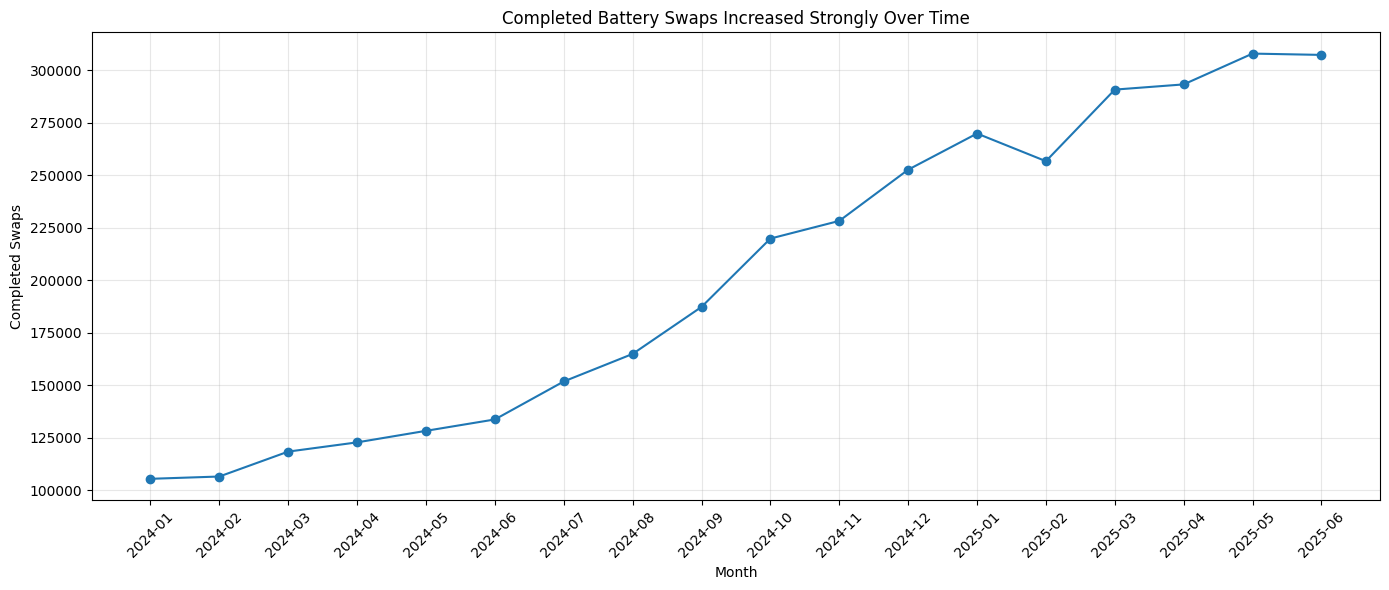

In [ ]:
# ============================================
# NETWORK VOLUME TREND
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["completed_swaps"],
    marker="o"
)

plt.title(
    "Completed Battery Swaps Increased Strongly Over Time"
)

plt.xlabel("Month")
plt.ylabel("Completed Swaps")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

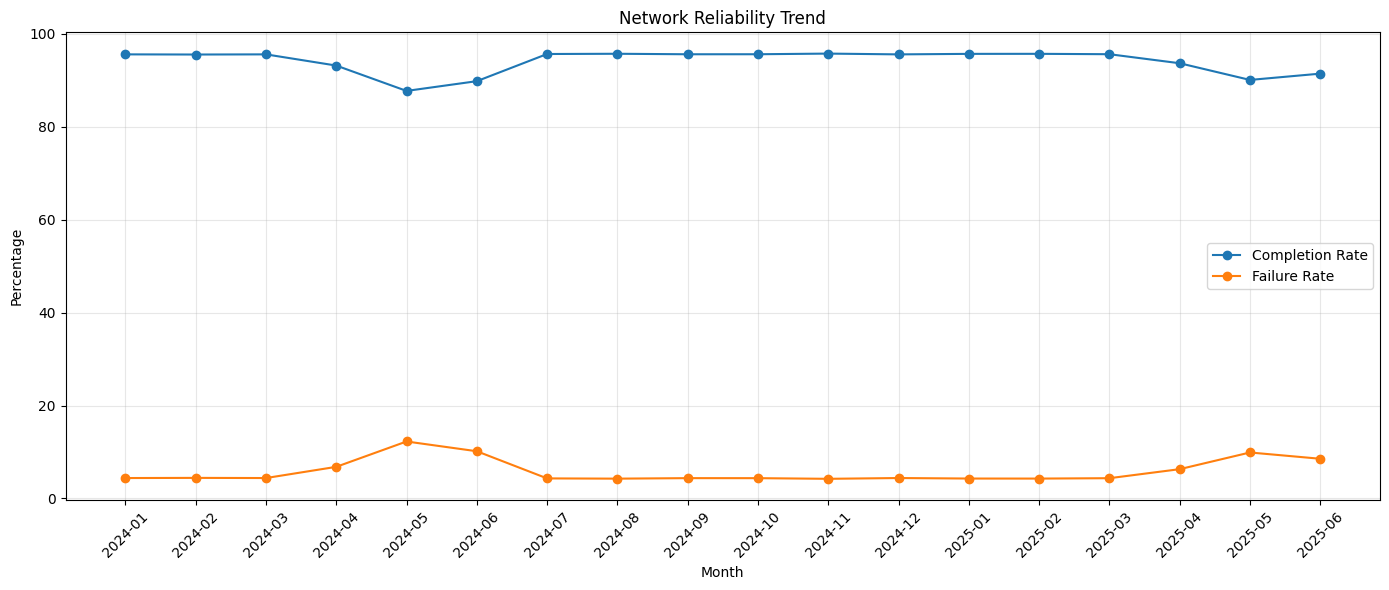

In [ ]:
# ============================================
# COMPLETION VS FAILURE RATE
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["completion_rate"],
    marker="o",
    label="Completion Rate"
)

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["failure_rate"],
    marker="o",
    label="Failure Rate"
)

plt.title(
    "Network Reliability Trend"
)

plt.xlabel("Month")
plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

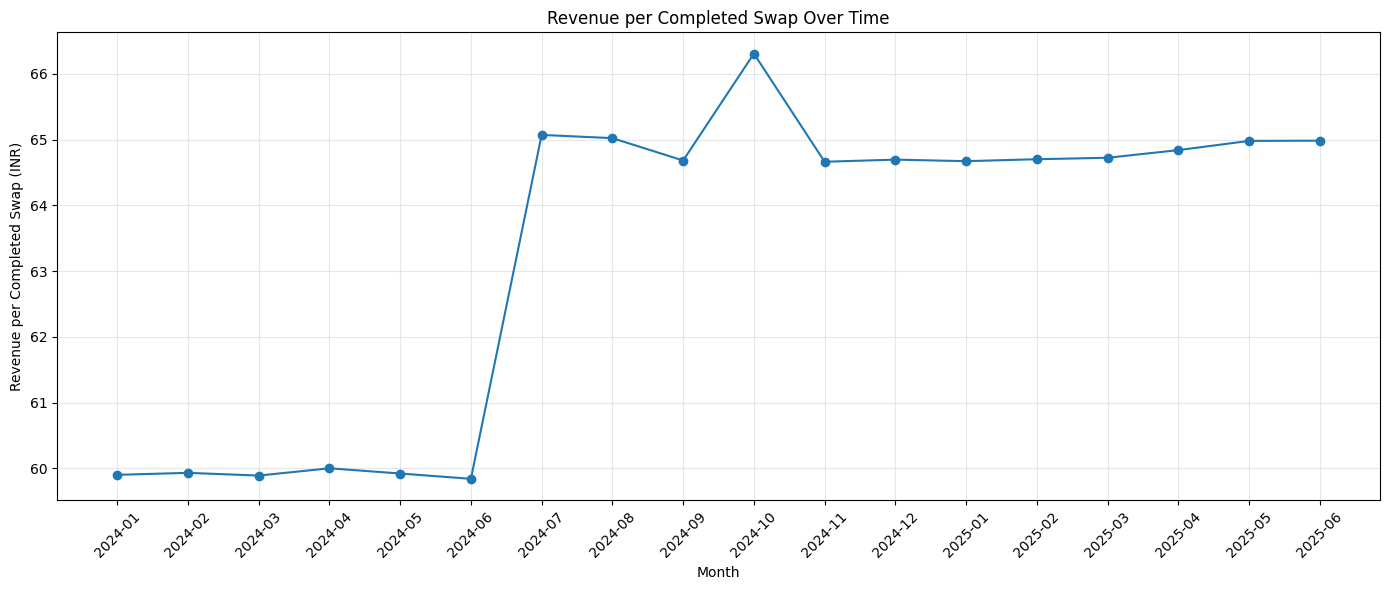

In [ ]:
# ============================================
# REVENUE PER COMPLETED SWAP
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_kpis["month"],
    monthly_kpis["revenue_per_completed"],
    marker="o"
)

plt.title(
    "Revenue per Completed Swap Over Time"
)

plt.xlabel("Month")
plt.ylabel("Revenue per Completed Swap (INR)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# CITY KPI
# ============================================

city_kpis = (
    pd.concat(city_data)
    .groupby("city")
    .agg(
        attempts=("attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

city_kpis["completion_rate"] = (
    city_kpis["completed_swaps"]
    / city_kpis["attempts"]
    * 100
)

city_kpis["failure_rate"] = (
    100 - city_kpis["completion_rate"]
)

city_kpis["revenue_per_completed"] = (
    city_kpis["revenue"]
    / city_kpis["completed_swaps"]
)

city_kpis = city_kpis.sort_values(
    "failure_rate",
    ascending=False
)

city_kpis

,city,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
3,Jaipur,487634,449366,"28,229,052.85",92.15,7.85,62.82
1,Delhi NCR,768913,712385,"44,565,107.85",92.65,7.35,62.56
2,Hyderabad,711930,664312,"41,521,622.25",93.31,6.69,62.50
5,Pune,552910,525331,"34,766,281.90",95.01,4.99,66.18
0,Bengaluru,825327,787697,"51,954,743.25",95.44,4.56,65.96
4,Mumbai,530299,506718,"32,089,247.45",95.55,4.45,63.33


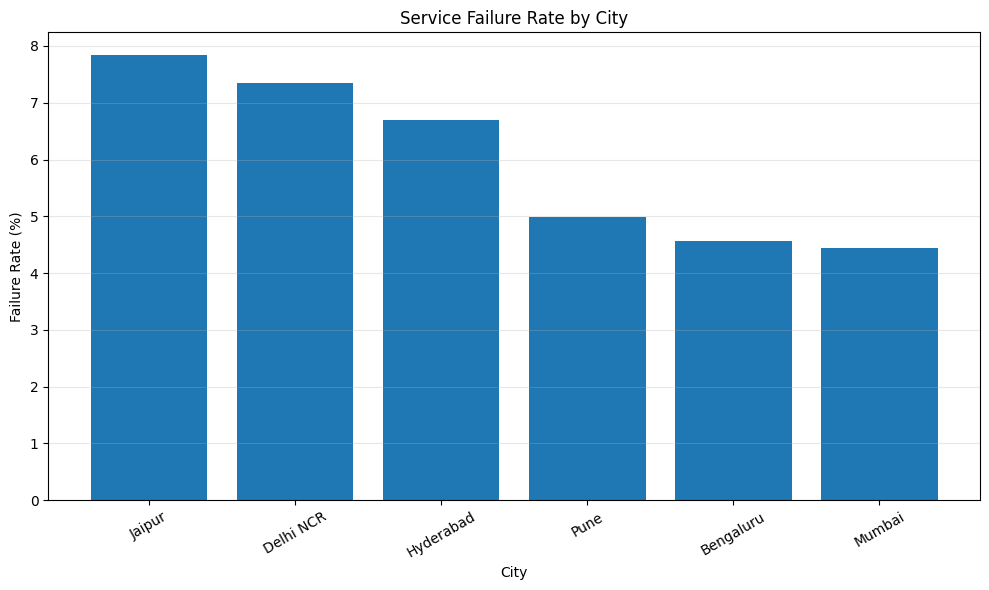

In [ ]:
# ============================================
# FAILURE RATE BY CITY
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    city_kpis["city"],
    city_kpis["failure_rate"]
)

plt.title(
    "Service Failure Rate by City"
)

plt.xlabel("City")
plt.ylabel("Failure Rate (%)")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# VEHICLE CLASS KPI
# ============================================

vehicle_kpis = (
    pd.concat(vehicle_data)
    .groupby("vehicle_class")
    .agg(
        attempts=("attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

vehicle_kpis["completion_rate"] = (
    vehicle_kpis["completed_swaps"]
    / vehicle_kpis["attempts"]
    * 100
)

vehicle_kpis["failure_rate"] = (
    100 - vehicle_kpis["completion_rate"]
)

vehicle_kpis["revenue_per_completed"] = (
    vehicle_kpis["revenue"]
    / vehicle_kpis["completed_swaps"]
)

vehicle_kpis

,vehicle_class,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
0,2W,3452996,3265675,"195,243,049.75",94.58,5.42,59.79
1,3W,424017,380134,"37,883,005.80",89.65,10.35,99.66


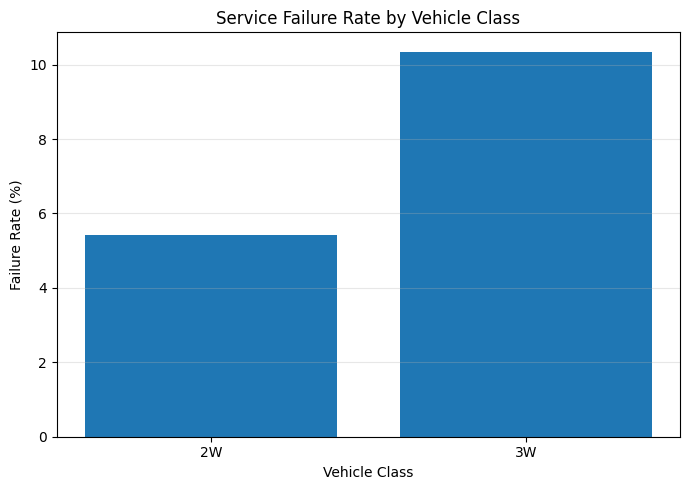

In [ ]:
# ============================================
# VEHICLE CLASS FAILURE RATE
# ============================================

plt.figure(figsize=(7, 5))

plt.bar(
    vehicle_kpis["vehicle_class"],
    vehicle_kpis["failure_rate"]
)

plt.title(
    "Service Failure Rate by Vehicle Class"
)

plt.xlabel("Vehicle Class")
plt.ylabel("Failure Rate (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# HOUR OF DAY KPI
# ============================================

hourly_kpis = (
    pd.concat(hour_data)
    .groupby("hour")
    .agg(
        attempts=("attempts", "sum"),
        completed_swaps=("completed_swaps", "sum")
    )
    .reset_index()
)

hourly_kpis["completion_rate"] = (
    hourly_kpis["completed_swaps"]
    / hourly_kpis["attempts"]
    * 100
)

hourly_kpis["failure_rate"] = (
    100 - hourly_kpis["completion_rate"]
)

hourly_kpis

,hour,attempts,completed_swaps,completion_rate,failure_rate
0,0,22364,21121,94.44,5.56
1,1,22153,20919,94.43,5.57
2,2,22266,21019,94.40,5.60
3,3,22246,21019,94.48,5.52
4,4,25345,24017,94.76,5.24
5,5,25171,23819,94.63,5.37
6,6,55566,52479,94.44,5.56
7,7,55816,52715,94.44,5.56
8,8,167469,157954,94.32,5.68
9,9,236569,223379,94.42,5.58


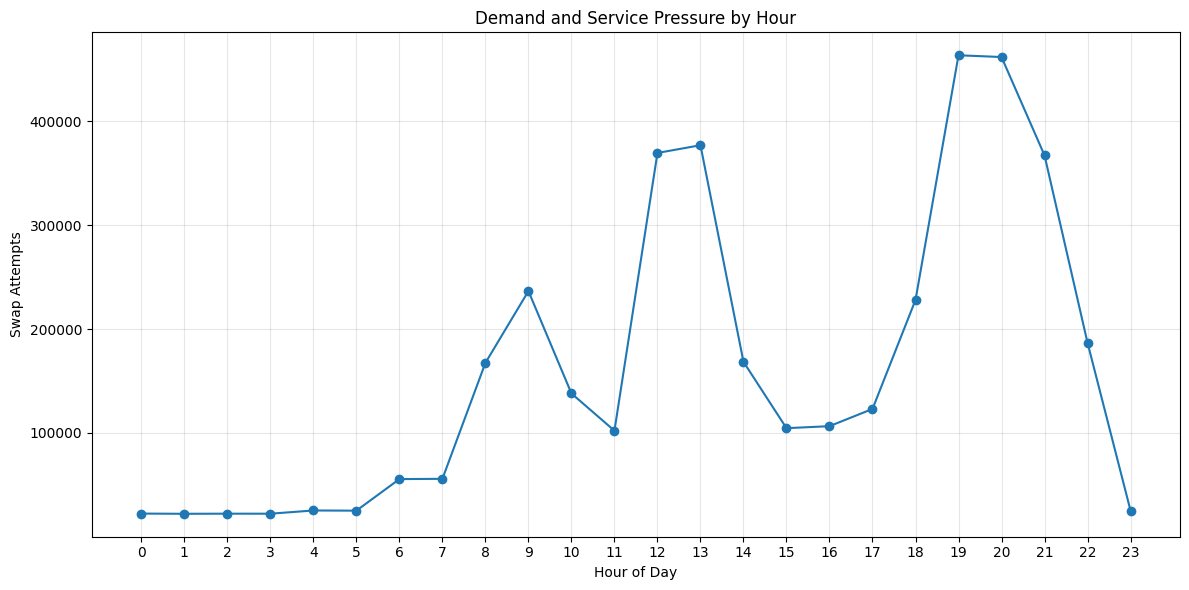

In [ ]:
# ============================================
# HOURLY FAILURE RATE
# ============================================

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    hourly_kpis["hour"],
    hourly_kpis["attempts"],
    marker="o"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Swap Attempts")

ax1.set_xticks(range(24))

ax1.grid(alpha=0.3)

plt.title(
    "Demand and Service Pressure by Hour"
)

plt.tight_layout()

plt.show()

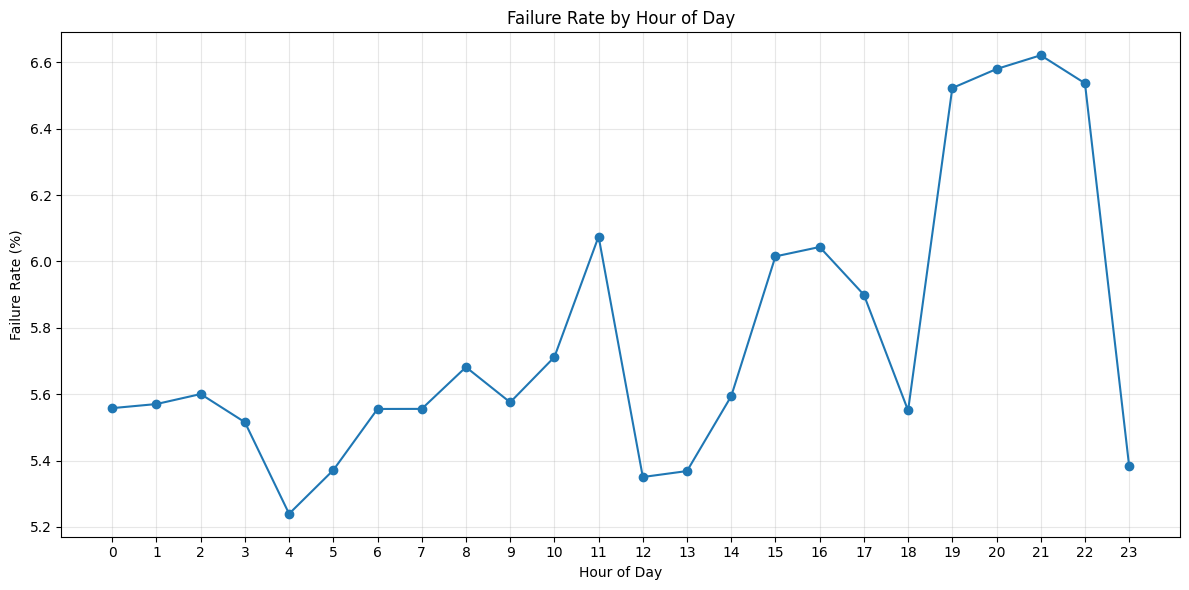

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_kpis["hour"],
    hourly_kpis["failure_rate"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")

plt.xticks(range(24))

plt.title(
    "Failure Rate by Hour of Day"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# STATION KPI
# ============================================

station_kpis = (
    pd.concat(station_data)
    .groupby(
        [
            "station_id",
            "city",
            "location_type",
            "charger_generation"
        ]
    )
    .agg(
        attempts=("attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

station_kpis["completion_rate"] = (
    station_kpis["completed_swaps"]
    / station_kpis["attempts"]
    * 100
)

station_kpis["failure_rate"] = (
    100 - station_kpis["completion_rate"]
)

station_kpis["revenue_per_completed"] = (
    station_kpis["revenue"]
    / station_kpis["completed_swaps"]
)

station_kpis = station_kpis.sort_values(
    "failure_rate",
    ascending=False
)

station_kpis.head(20)

,station_id,city,location_type,charger_generation,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
36,STN-DEL-037,Delhi NCR,commercial_hub,Gen1,30838,28039,"1,753,081.65",90.92,9.08,62.52
47,STN-DEL-048,Delhi NCR,market,Gen1,34646,31535,"1,942,066.85",91.02,8.98,61.58
92,STN-JAI-137,Jaipur,commercial_hub,Gen1,44371,40490,"2,529,267.85",91.25,8.75,62.47
97,STN-JAI-142,Jaipur,commercial_hub,Gen1,33319,30405,"1,946,904.75",91.25,8.75,64.03
96,STN-JAI-141,Jaipur,commercial_hub,Gen1,45594,41613,"2,528,249.90",91.27,8.73,60.76
44,STN-DEL-045,Delhi NCR,commercial_hub,Gen1,32237,29426,"1,835,646.25",91.28,8.72,62.38
91,STN-JAI-136,Jaipur,transit_hub,Gen1,29340,26785,"1,747,866.15",91.29,8.71,65.26
93,STN-JAI-138,Jaipur,market,Gen1,48945,44703,"2,804,974.60",91.33,8.67,62.75
39,STN-DEL-040,Delhi NCR,market,Gen1,40335,36848,"2,364,370.60",91.35,8.65,64.17
49,STN-DEL-050,Delhi NCR,commercial_hub,Gen1,47060,43007,"2,639,130.25",91.39,8.61,61.37


In [ ]:
# ============================================
# HIGH-VOLUME + HIGH-FAILURE STATIONS
# ============================================

volume_threshold = station_kpis["attempts"].quantile(0.75)
failure_threshold = station_kpis["failure_rate"].quantile(0.75)

priority_stations = station_kpis[
    (station_kpis["attempts"] >= volume_threshold) &
    (station_kpis["failure_rate"] >= failure_threshold)
].copy()

priority_stations = priority_stations.sort_values(
    ["failure_rate", "attempts"],
    ascending=[False, False]
)

print("High-volume, high-failure stations:")
print(
    priority_stations[
        [
            "station_id",
            "city",
            "attempts",
            "failure_rate",
            "completion_rate",
            "revenue_per_completed"
        ]
    ].to_string(index=False)
)

High-volume, high-failure stations:
 station_id      city  attempts  failure_rate  completion_rate  revenue_per_completed
STN-JAI-137    Jaipur     44371          8.75            91.25                  62.47
STN-JAI-141    Jaipur     45594          8.73            91.27                  60.76
STN-JAI-138    Jaipur     48945          8.67            91.33                  62.75
STN-DEL-040 Delhi NCR     40335          8.65            91.35                  64.17
STN-DEL-050 Delhi NCR     47060          8.61            91.39                  61.37
STN-DEL-043 Delhi NCR     49597          8.61            91.39                  61.83
STN-DEL-036 Delhi NCR     35499          8.54            91.46                  60.71
STN-JAI-140    Jaipur     44115          8.46            91.54                  61.90
STN-DEL-047 Delhi NCR     41594          8.44            91.56                  63.40
STN-JAI-134    Jaipur     42925          8.41            91.59                  61.92
STN-HYD-072 Hydera

In [ ]:
# ============================================
# HIGH-VOLUME + HIGH-FAILURE STATIONS
# ============================================

volume_threshold = station_kpis["attempts"].quantile(0.75)
failure_threshold = station_kpis["failure_rate"].quantile(0.75)

priority_stations = station_kpis[
    (station_kpis["attempts"] >= volume_threshold) &
    (station_kpis["failure_rate"] >= failure_threshold)
].copy()

priority_stations = priority_stations.sort_values(
    ["failure_rate", "attempts"],
    ascending=[False, False]
)

print("High-volume, high-failure stations:")
print(
    priority_stations[
        [
            "station_id",
            "city",
            "attempts",
            "failure_rate",
            "completion_rate",
            "revenue_per_completed"
        ]
    ].to_string(index=False)
)

High-volume, high-failure stations:
 station_id      city  attempts  failure_rate  completion_rate  revenue_per_completed
STN-JAI-137    Jaipur     44371          8.75            91.25                  62.47
STN-JAI-141    Jaipur     45594          8.73            91.27                  60.76
STN-JAI-138    Jaipur     48945          8.67            91.33                  62.75
STN-DEL-040 Delhi NCR     40335          8.65            91.35                  64.17
STN-DEL-050 Delhi NCR     47060          8.61            91.39                  61.37
STN-DEL-043 Delhi NCR     49597          8.61            91.39                  61.83
STN-DEL-036 Delhi NCR     35499          8.54            91.46                  60.71
STN-JAI-140    Jaipur     44115          8.46            91.54                  61.90
STN-DEL-047 Delhi NCR     41594          8.44            91.56                  63.40
STN-JAI-134    Jaipur     42925          8.41            91.59                  61.92
STN-HYD-072 Hydera

In [ ]:
# ============================================
# FAILURE REASONS
# ============================================

event_kpis = (
    pd.concat(event_data)
    .groupby("event_type")
    .agg(
        attempts=("attempts", "sum")
    )
    .reset_index()
)

event_kpis["percentage"] = (
    event_kpis["attempts"]
    / event_kpis["attempts"].sum()
    * 100
)

event_kpis = event_kpis.sort_values(
    "attempts",
    ascending=False
)

event_kpis

,event_type,attempts,percentage
4,swap_completed,3645809,94.04
2,failed_no_charged_battery,134389,3.47
0,abandoned_queue,68533,1.77
1,cancelled_by_rider,16712,0.43
3,failed_system_error,11570,0.30


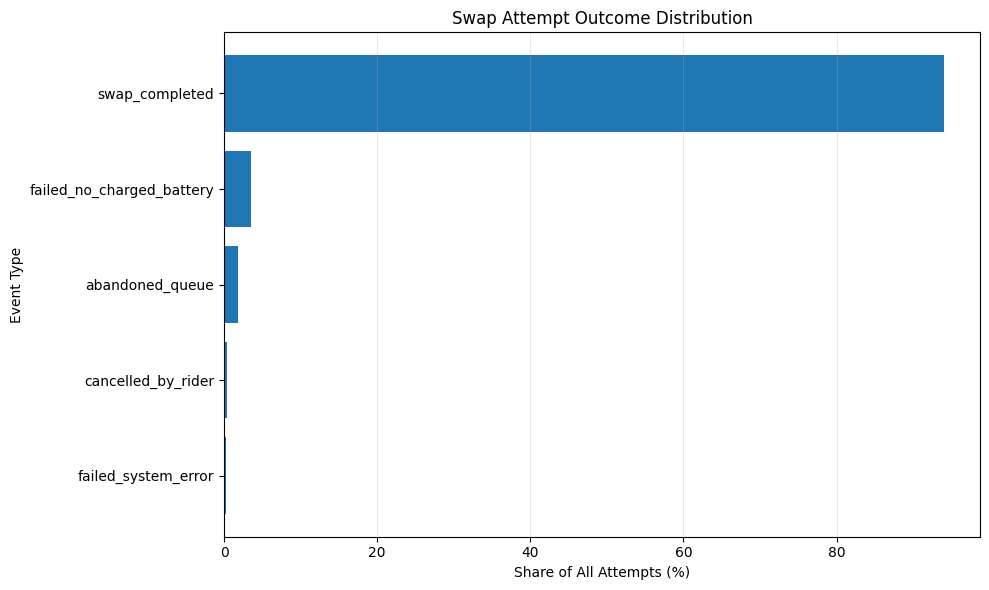

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    event_kpis["event_type"],
    event_kpis["percentage"]
)

plt.xlabel("Share of All Attempts (%)")
plt.ylabel("Event Type")

plt.title(
    "Swap Attempt Outcome Distribution"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# SAVE ANALYSIS TABLES
# ============================================

monthly_kpis.to_csv(
    "/content/monthly_kpis.csv",
    index=False
)

city_kpis.to_csv(
    "/content/city_kpis.csv",
    index=False
)

vehicle_kpis.to_csv(
    "/content/vehicle_kpis.csv",
    index=False
)

hourly_kpis.to_csv(
    "/content/hourly_kpis.csv",
    index=False
)

station_kpis.to_csv(
    "/content/station_kpis.csv",
    index=False
)

event_kpis.to_csv(
    "/content/event_kpis.csv",
    index=False
)

print("All analysis tables saved.")

All analysis tables saved.


In [ ]:
monthly_kpis

,month,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
0,2024-01,110348,105490,"6,318,995.20",95.60,4.40,59.90
1,2024-02,111531,106582,"6,387,614.80",95.56,4.44,59.93
2,2024-03,123900,118444,"7,093,617.00",95.60,4.40,59.89
3,2024-04,131818,122836,"7,370,255.80",93.19,6.81,60.00
4,2024-05,146278,128328,"7,689,594.00",87.73,12.27,59.92
5,2024-06,148888,133743,"8,003,275.60",89.83,10.17,59.84
6,2024-07,158688,151824,"9,879,524.60",95.67,4.33,65.07
7,2024-08,172295,164931,"10,724,296.65",95.73,4.27,65.02
8,2024-09,195885,187302,"12,115,209.50",95.62,4.38,64.68
9,2024-10,229901,219838,"14,577,271.65",95.62,4.38,66.31


In [ ]:
city_kpis

,city,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
3,Jaipur,487634,449366,"28,229,052.85",92.15,7.85,62.82
1,Delhi NCR,768913,712385,"44,565,107.85",92.65,7.35,62.56
2,Hyderabad,711930,664312,"41,521,622.25",93.31,6.69,62.50
5,Pune,552910,525331,"34,766,281.90",95.01,4.99,66.18
0,Bengaluru,825327,787697,"51,954,743.25",95.44,4.56,65.96
4,Mumbai,530299,506718,"32,089,247.45",95.55,4.45,63.33


In [ ]:
vehicle_kpis

,vehicle_class,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
0,2W,3452996,3265675,"195,243,049.75",94.58,5.42,59.79
1,3W,424017,380134,"37,883,005.80",89.65,10.35,99.66


In [ ]:
priority_stations

,station_id,city,location_type,charger_generation,attempts,completed_swaps,revenue,completion_rate,failure_rate,revenue_per_completed
92,STN-JAI-137,Jaipur,commercial_hub,Gen1,44371,40490,"2,529,267.85",91.25,8.75,62.47
96,STN-JAI-141,Jaipur,commercial_hub,Gen1,45594,41613,"2,528,249.90",91.27,8.73,60.76
93,STN-JAI-138,Jaipur,market,Gen1,48945,44703,"2,804,974.60",91.33,8.67,62.75
39,STN-DEL-040,Delhi NCR,market,Gen1,40335,36848,"2,364,370.60",91.35,8.65,64.17
49,STN-DEL-050,Delhi NCR,commercial_hub,Gen1,47060,43007,"2,639,130.25",91.39,8.61,61.37
42,STN-DEL-043,Delhi NCR,commercial_hub,Gen1,49597,45326,"2,802,302.45",91.39,8.61,61.83
35,STN-DEL-036,Delhi NCR,market,Gen1,35499,32468,"1,971,006.70",91.46,8.54,60.71
95,STN-JAI-140,Jaipur,commercial_hub,Gen1,44115,40382,"2,499,628.70",91.54,8.46,61.90
46,STN-DEL-047,Delhi NCR,market,Gen1,41594,38085,"2,414,664.20",91.56,8.44,63.40
89,STN-JAI-134,Jaipur,commercial_hub,Gen1,42925,39313,"2,434,335.95",91.59,8.41,61.92


In [ ]:
# ============================================
# BATTERY + STATION LOOKUPS
# ============================================

battery_lookup = batteries[
    [
        "battery_id",
        "pack_type",
        "supplier",
        "manufacturing_lot",
        "rated_capacity_kwh",
        "purchase_cost_inr",
        "initial_soh_pct",
        "current_soh_pct"
    ]
].copy()

station_cost_lookup = stations[
    [
        "station_id",
        "city",
        "grid_tariff_inr_kwh",
        "monthly_rent_inr",
        "monthly_maintenance_inr",
        "charger_generation"
    ]
].copy()

rider_partner_lookup = riders[
    [
        "rider_id",
        "partner_id",
        "vehicle_class",
        "plan_type"
    ]
].copy()

partner_lookup = fleet_partners[
    [
        "partner_id",
        "partner_name",
        "partner_segment",
        "contract_type",
        "discount_pct",
        "amendment_date",
        "discount_pct_after_amendment",
        "peak_surcharge_billable"
    ]
].copy()

print("Battery lookup:", battery_lookup.shape)
print("Station cost lookup:", station_cost_lookup.shape)
print("Partner lookup:", partner_lookup.shape)

Battery lookup: (6500, 8)
Station cost lookup: (152, 6)
Partner lookup: (12, 8)


In [ ]:
# ============================================
# FAST LOOKUPS
# ============================================

battery_supplier = dict(
    zip(battery_lookup["battery_id"], battery_lookup["supplier"])
)

battery_lot = dict(
    zip(battery_lookup["battery_id"], battery_lookup["manufacturing_lot"])
)

battery_pack_type = dict(
    zip(battery_lookup["battery_id"], battery_lookup["pack_type"])
)

battery_purchase_cost = dict(
    zip(battery_lookup["battery_id"], battery_lookup["purchase_cost_inr"])
)

station_tariff = dict(
    zip(
        station_cost_lookup["station_id"],
        station_cost_lookup["grid_tariff_inr_kwh"]
    )
)

station_rent = dict(
    zip(
        station_cost_lookup["station_id"],
        station_cost_lookup["monthly_rent_inr"]
    )
)

station_maintenance = dict(
    zip(
        station_cost_lookup["station_id"],
        station_cost_lookup["monthly_maintenance_inr"]
    )
)

station_city_map = dict(
    zip(
        station_cost_lookup["station_id"],
        station_cost_lookup["city"]
    )
)

rider_partner = dict(
    zip(
        rider_partner_lookup["rider_id"],
        rider_partner_lookup["partner_id"]
    )
)

rider_plan = dict(
    zip(
        rider_partner_lookup["rider_id"],
        rider_partner_lookup["plan_type"]
    )
)

print("All lookups ready.")

All lookups ready.


In [ ]:
# ============================================
# PROCESS PRICING + BATTERY DATA
# ============================================

SWAP_FILE = "/content/swap_data/swap_events.csv"

pricing_data = []
supplier_data = []
pack_data = []
partner_data = []
margin_monthly_data = []

usecols = [
    "event_id",
    "rider_id",
    "station_id",
    "event_ts",
    "event_type",
    "battery_in_id",
    "battery_out_id",
    "soh_in_pct",
    "soh_out_pct",
    "km_since_last_swap",
    "tariff_code",
    "list_price_inr",
    "discount_inr",
    "amount_charged_inr",
    "energy_to_recharge_kwh"
]

chunk_no = 0

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=usecols,
    chunksize=250_000
):

    chunk_no += 1

    # ----------------------------------------
    # Datetime
    # ----------------------------------------
    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    chunk["month"] = (
        chunk["event_ts"]
        .dt.to_period("M")
        .astype(str)
    )

    # ----------------------------------------
    # Completed swaps only for revenue/
    # energy/margin analysis
    # ----------------------------------------
    completed = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    if len(completed) == 0:
        continue

    # ----------------------------------------
    # Station energy tariff
    # ----------------------------------------
    completed["grid_tariff"] = (
        completed["station_id"]
        .map(station_tariff)
    )

    completed["energy_cost"] = (
        completed["energy_to_recharge_kwh"]
        * completed["grid_tariff"]
    )

    # ----------------------------------------
    # Direct contribution margin
    # Revenue minus energy cost
    # ----------------------------------------
    completed["direct_contribution"] = (
        completed["amount_charged_inr"]
        - completed["energy_cost"]
    )

    # ----------------------------------------
    # Pricing analysis
    # ----------------------------------------
    pricing = (
        completed
        .groupby("tariff_code")
        .agg(
            completed_swaps=("event_id", "count"),
            list_revenue=("list_price_inr", "sum"),
            discounts=("discount_inr", "sum"),
            revenue=("amount_charged_inr", "sum"),
            energy_cost=("energy_cost", "sum"),
            direct_contribution=("direct_contribution", "sum")
        )
        .reset_index()
    )

    pricing_data.append(pricing)

    # ----------------------------------------
    # Monthly contribution
    # ----------------------------------------
    monthly_margin = (
        completed
        .groupby("month")
        .agg(
            completed_swaps=("event_id", "count"),
            revenue=("amount_charged_inr", "sum"),
            energy_cost=("energy_cost", "sum"),
            direct_contribution=("direct_contribution", "sum")
        )
        .reset_index()
    )

    margin_monthly_data.append(monthly_margin)

    # ----------------------------------------
    # Battery supplier
    # ----------------------------------------
    completed["supplier"] = (
        completed["battery_out_id"]
        .map(battery_supplier)
    )

    completed["manufacturing_lot"] = (
        completed["battery_out_id"]
        .map(battery_lot)
    )

    completed["pack_type"] = (
        completed["battery_out_id"]
        .map(battery_pack_type)
    )

    supplier = (
        completed
        .groupby("supplier")
        .agg(
            completed_swaps=("event_id", "count"),
            avg_soh_out=("soh_out_pct", "mean"),
            avg_soh_in=("soh_in_pct", "mean"),
            avg_range_km=("km_since_last_swap", "mean"),
            revenue=("amount_charged_inr", "sum"),
            energy_cost=("energy_cost", "sum"),
            contribution=("direct_contribution", "sum")
        )
        .reset_index()
    )

    supplier_data.append(supplier)

    # ----------------------------------------
    # Battery pack type
    # ----------------------------------------
    pack = (
        completed
        .groupby("pack_type")
        .agg(
            completed_swaps=("event_id", "count"),
            avg_soh_out=("soh_out_pct", "mean"),
            avg_soh_in=("soh_in_pct", "mean"),
            avg_range_km=("km_since_last_swap", "mean"),
            revenue=("amount_charged_inr", "sum"),
            energy_cost=("energy_cost", "sum"),
            contribution=("direct_contribution", "sum")
        )
        .reset_index()
    )

    pack_data.append(pack)

    # ----------------------------------------
    # Partner mapping
    # ----------------------------------------
    completed["partner_id"] = (
        completed["rider_id"]
        .map(rider_partner)
    )

    partner = (
        completed
        .groupby("partner_id", dropna=False)
        .agg(
            completed_swaps=("event_id", "count"),
            revenue=("amount_charged_inr", "sum"),
            discounts=("discount_inr", "sum"),
            energy_cost=("energy_cost", "sum"),
            contribution=("direct_contribution", "sum")
        )
        .reset_index()
    )

    partner_data.append(partner)

    print(f"Chunk {chunk_no} processed")

print("\n processing completed.")

Chunk 1 processed
Chunk 2 processed
Chunk 3 processed
Chunk 4 processed
Chunk 5 processed
Chunk 6 processed
Chunk 7 processed
Chunk 8 processed
Chunk 9 processed
Chunk 10 processed
Chunk 11 processed
Chunk 12 processed
Chunk 13 processed
Chunk 14 processed
Chunk 15 processed
Chunk 16 processed

 processing completed.


In [ ]:
# ============================================
# PRICING KPI
# ============================================

pricing_kpis = (
    pd.concat(pricing_data)
    .groupby("tariff_code")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        list_revenue=("list_revenue", "sum"),
        discounts=("discounts", "sum"),
        revenue=("revenue", "sum"),
        energy_cost=("energy_cost", "sum"),
        direct_contribution=("direct_contribution", "sum")
    )
    .reset_index()
)

pricing_kpis["avg_revenue_per_swap"] = (
    pricing_kpis["revenue"]
    / pricing_kpis["completed_swaps"]
)

pricing_kpis["avg_energy_cost_per_swap"] = (
    pricing_kpis["energy_cost"]
    / pricing_kpis["completed_swaps"]
)

pricing_kpis["contribution_per_swap"] = (
    pricing_kpis["direct_contribution"]
    / pricing_kpis["completed_swaps"]
)

pricing_kpis["discount_rate"] = (
    pricing_kpis["discounts"]
    / pricing_kpis["list_revenue"]
    * 100
)

pricing_kpis.sort_values(
    "contribution_per_swap",
    ascending=False
)

,tariff_code,completed_swaps,list_revenue,discounts,revenue,energy_cost,direct_contribution,avg_revenue_per_swap,avg_energy_cost_per_swap,contribution_per_swap,discount_rate
2,PEAK,169833,"11,472,360.00",0.00,"14,019,900.00","2,944,097.10","11,075,802.90",82.55,17.34,65.22,0.00
3,STD,1030037,"68,203,320.00",0.00,"68,203,295.00","18,895,057.80","49,308,237.20",66.21,18.34,47.87,0.00
0,OFFPEAK,36098,"2,438,035.00",0.00,"2,149,346.00","625,938.41","1,523,407.59",59.54,17.34,42.20,0.00
1,PARTNER,2409841,"167,994,585.00","21,228,532.45","148,753,514.55","48,622,032.80","100,131,481.75",61.73,20.18,41.55,12.64


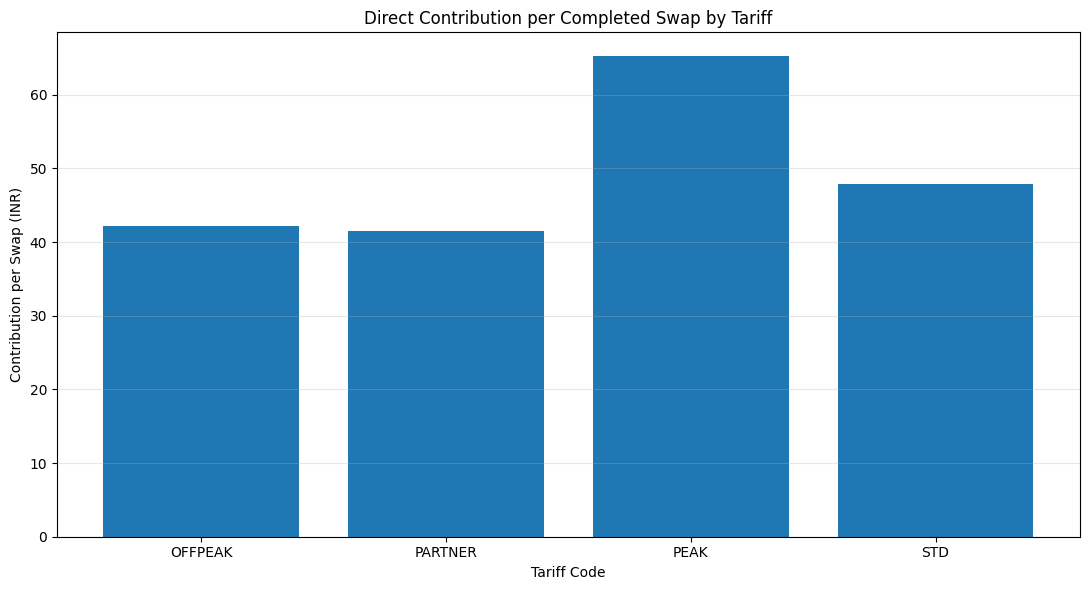

In [ ]:
plt.figure(figsize=(11, 6))

plt.bar(
    pricing_kpis["tariff_code"],
    pricing_kpis["contribution_per_swap"]
)

plt.title(
    "Direct Contribution per Completed Swap by Tariff"
)

plt.xlabel("Tariff Code")
plt.ylabel("Contribution per Swap (INR)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# MONTHLY DIRECT CONTRIBUTION
# ============================================

monthly_margin = (
    pd.concat(margin_monthly_data)
    .groupby("month")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        energy_cost=("energy_cost", "sum"),
        direct_contribution=("direct_contribution", "sum")
    )
    .reset_index()
)

monthly_margin["contribution_per_swap"] = (
    monthly_margin["direct_contribution"]
    / monthly_margin["completed_swaps"]
)

monthly_margin

,month,completed_swaps,revenue,energy_cost,direct_contribution,contribution_per_swap
0,2024-01,105490,"6,318,995.20","2,320,971.24","3,998,023.96",37.90
1,2024-02,106582,"6,387,614.80","2,334,290.44","4,053,324.36",38.03
2,2024-03,118444,"7,093,617.00","2,572,346.56","4,521,270.44",38.17
3,2024-04,122836,"7,370,255.80","2,652,598.93","4,717,656.87",38.41
4,2024-05,128328,"7,689,594.00","2,738,029.26","4,951,564.74",38.59
5,2024-06,133743,"8,003,275.60","2,813,405.94","5,189,869.66",38.80
6,2024-07,151824,"9,879,524.60","3,166,309.81","6,713,214.79",44.22
7,2024-08,164931,"10,724,296.65","3,405,336.13","7,318,960.52",44.38
8,2024-09,187302,"12,115,209.50","3,830,745.92","8,284,463.58",44.23
9,2024-10,219838,"14,577,271.65","4,444,666.63","10,132,605.02",46.09


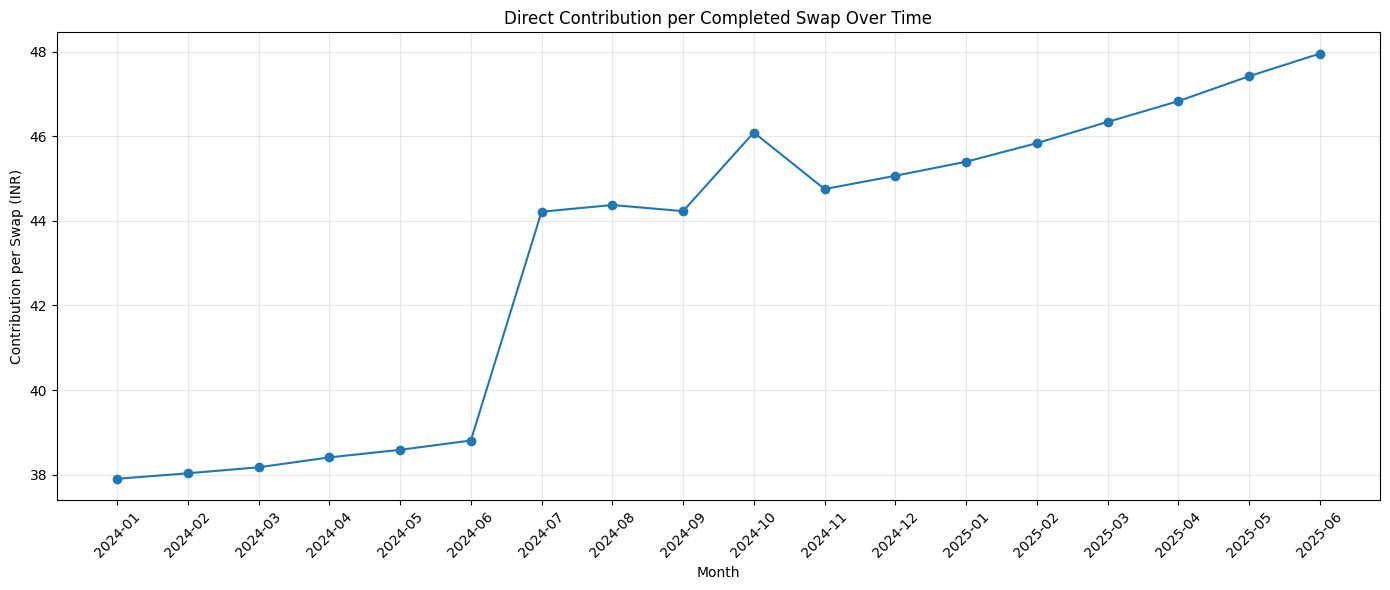

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_margin["month"],
    monthly_margin["contribution_per_swap"],
    marker="o"
)

plt.title(
    "Direct Contribution per Completed Swap Over Time"
)

plt.xlabel("Month")
plt.ylabel("Contribution per Swap (INR)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# SUPPLIER KPI
# ============================================

supplier_kpis = (
    pd.concat(supplier_data)
    .groupby("supplier")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        energy_cost=("energy_cost", "sum"),
        contribution=("contribution", "sum"),
        avg_soh_out=("avg_soh_out", "mean"),
        avg_soh_in=("avg_soh_in", "mean"),
        avg_range_km=("avg_range_km", "mean")
    )
    .reset_index()
)

supplier_kpis["contribution_per_swap"] = (
    supplier_kpis["contribution"]
    / supplier_kpis["completed_swaps"]
)

supplier_kpis

,supplier,completed_swaps,revenue,energy_cost,contribution,avg_soh_out,avg_soh_in,avg_range_km,contribution_per_swap
0,Amptek,799484,"51,032,756.75","15,781,928.47","35,250,828.28",89.07,88.02,62.37,44.09
1,Cellora,2188677,"138,898,222.30","42,743,832.47","96,154,389.83",89.03,87.98,62.13,43.93
2,Kyron,657648,"43,195,076.50","12,561,365.16","30,633,711.34",85.08,87.49,65.53,46.58


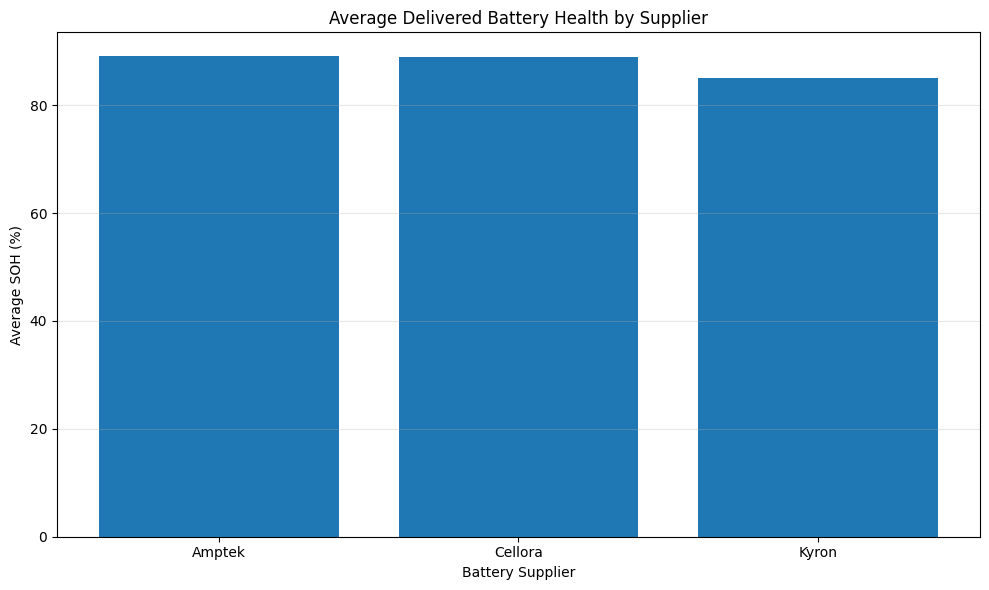

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    supplier_kpis["supplier"],
    supplier_kpis["avg_soh_out"]
)

ax.set_title(
    "Average Delivered Battery Health by Supplier"
)

ax.set_xlabel("Battery Supplier")
ax.set_ylabel("Average SOH (%)")

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

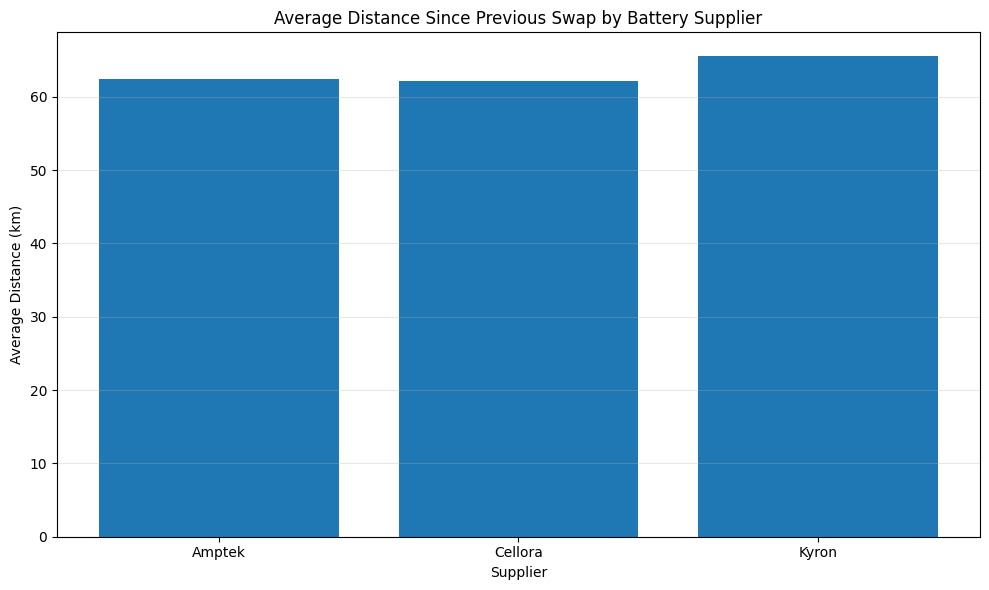

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    supplier_kpis["supplier"],
    supplier_kpis["avg_range_km"]
)

plt.title(
    "Average Distance Since Previous Swap by Battery Supplier"
)

plt.xlabel("Supplier")
plt.ylabel("Average Distance (km)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# BATTERY PACK TYPE
# ============================================

pack_kpis = (
    pd.concat(pack_data)
    .groupby("pack_type")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        energy_cost=("energy_cost", "sum"),
        contribution=("contribution", "sum"),
        avg_soh_out=("avg_soh_out", "mean"),
        avg_soh_in=("avg_soh_in", "mean"),
        avg_range_km=("avg_range_km", "mean")
    )
    .reset_index()
)

pack_kpis["contribution_per_swap"] = (
    pack_kpis["contribution"]
    / pack_kpis["completed_swaps"]
)

pack_kpis

,pack_type,completed_swaps,revenue,energy_cost,contribution,avg_soh_out,avg_soh_in,avg_range_km,contribution_per_swap
0,2W_2.1kWh,3265675,"195,243,049.75","55,554,957.61","139,688,092.14",87.55,87.30,58.37,42.77
1,3W_4.8kWh,380134,"37,883,005.80","15,532,168.50","22,350,837.30",91.99,92.03,89.60,58.80


In [ ]:
# ============================================
# FLEET PARTNER ECONOMICS
# ============================================

partner_kpis = (
    pd.concat(partner_data)
    .groupby("partner_id", dropna=False)
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        discounts=("discounts", "sum"),
        energy_cost=("energy_cost", "sum"),
        contribution=("contribution", "sum")
    )
    .reset_index()
)

# Remove independent riders for partner analysis
partner_kpis = partner_kpis[
    partner_kpis["partner_id"].notna()
].copy()

# Add partner details
partner_kpis = partner_kpis.merge(
    partner_lookup,
    on="partner_id",
    how="left"
)

partner_kpis["revenue_per_swap"] = (
    partner_kpis["revenue"]
    / partner_kpis["completed_swaps"]
)

partner_kpis["contribution_per_swap"] = (
    partner_kpis["contribution"]
    / partner_kpis["completed_swaps"]
)

partner_kpis["discount_rate_observed"] = (
    partner_kpis["discounts"]
    / (
        partner_kpis["revenue"]
        + partner_kpis["discounts"]
    )
    * 100
)

partner_kpis = partner_kpis.sort_values(
    "contribution_per_swap",
    ascending=False
)

partner_kpis

,partner_id,completed_swaps,revenue,discounts,energy_cost,contribution,partner_name,partner_segment,contract_type,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,revenue_per_swap,contribution_per_swap,discount_rate_observed
8,FP-09,54274,"5,445,913.90","409,579.10","2,210,512.48","3,235,401.42",HaulKing,cargo_3w,pay_per_swap,7.00,NaT,NaN,Y,100.34,59.61,6.99
3,FP-04,134085,"13,333,431.20","1,158,048.80","5,465,633.29","7,867,797.91",CargoTuk,cargo_3w,pay_per_swap,8.00,NaT,NaN,Y,99.44,58.68,7.99
7,FP-08,93376,"5,953,223.20","497,578.80","1,691,094.63","4,262,128.57",DabbaXpress,food_delivery,pay_per_swap,8.00,NaT,NaN,Y,63.76,45.64,7.71
11,FP-12,83854,"5,322,144.75","277,021.25","1,528,220.50","3,793,924.25",UrbanErrand,bike_taxi,pay_per_swap,5.00,NaT,NaN,Y,63.47,45.24,4.95
5,FP-06,120695,"7,569,963.90","477,833.10","2,164,123.55","5,405,840.35",RideMitra,bike_taxi,pay_per_swap,6.00,NaT,NaN,Y,62.72,44.79,5.94
6,FP-07,129967,"8,062,439.00","769,356.00","2,322,485.89","5,739,953.11",QuickCart,quick_commerce,pay_per_swap,9.00,NaT,NaN,Y,62.03,44.16,8.71
0,FP-01,526620,"32,696,006.00","3,497,118.00","9,581,833.46","23,114,172.54",FeastFly,food_delivery,volume_tiered,10.00,NaT,NaN,Y,62.09,43.89,9.66
10,FP-11,82103,"4,981,669.00","551,644.00","1,532,154.04","3,449,514.96",LastMileHub,ecom_logistics,pay_per_swap,10.00,NaT,NaN,Y,60.68,42.01,9.97
4,FP-05,241689,"14,336,840.65","1,771,944.35","4,440,310.58","9,896,530.07",Swiggle Go,food_delivery,volume_tiered,11.00,NaT,NaN,N,59.32,40.95,11.00
9,FP-10,83500,"4,922,457.00","668,805.00","1,530,270.58","3,392,186.42",MetroMove,ecom_logistics,volume_tiered,12.00,NaT,NaN,Y,58.95,40.62,11.96


In [ ]:
partner_segment_kpis = (
    partner_kpis
    .groupby("partner_segment")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        discounts=("discounts", "sum"),
        energy_cost=("energy_cost", "sum"),
        contribution=("contribution", "sum")
    )
    .reset_index()
)

partner_segment_kpis["contribution_per_swap"] = (
    partner_segment_kpis["contribution"]
    / partner_segment_kpis["completed_swaps"]
)

partner_segment_kpis["revenue_per_swap"] = (
    partner_segment_kpis["revenue"]
    / partner_segment_kpis["completed_swaps"]
)

partner_segment_kpis

,partner_segment,completed_swaps,revenue,discounts,energy_cost,contribution,contribution_per_swap,revenue_per_swap
0,bike_taxi,204549,"12,892,108.65","754,854.35","3,692,344.06","9,199,764.59",44.98,63.03
1,cargo_3w,188359,"18,779,345.10","1,567,627.90","7,676,145.77","11,103,199.33",58.95,99.70
2,ecom_logistics,468109,"27,017,840.75","4,231,149.25","8,554,747.44","18,463,093.31",39.44,57.72
3,food_delivery,861685,"52,986,069.85","5,766,641.15","15,713,238.67","37,272,831.18",43.26,61.49
4,quick_commerce,687139,"37,078,150.20","8,908,259.80","12,985,556.87","24,092,593.33",35.06,53.96


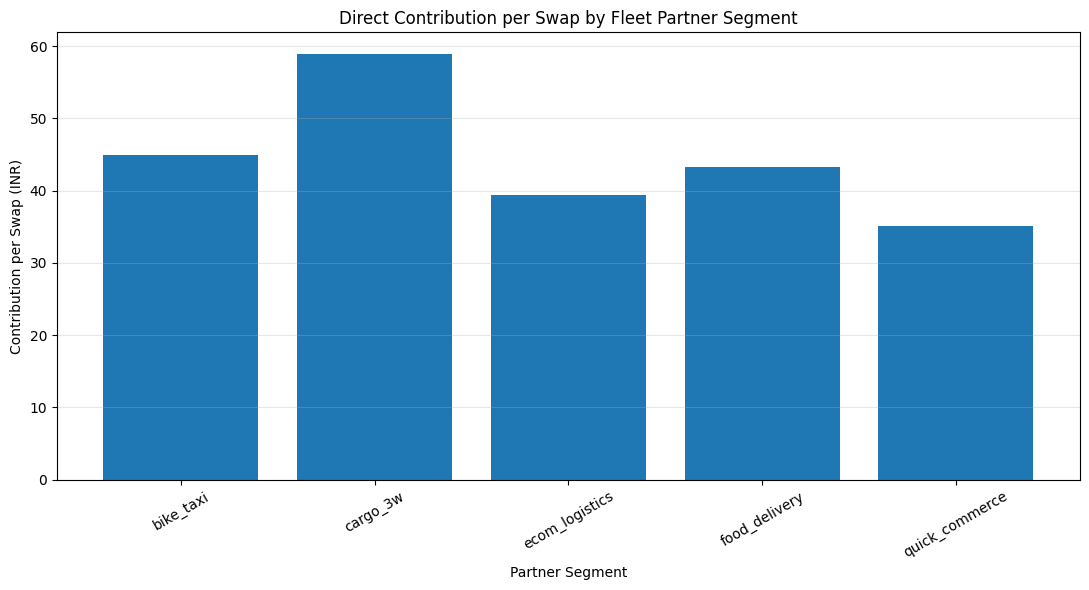

In [ ]:
plt.figure(figsize=(11, 6))

plt.bar(
    partner_segment_kpis["partner_segment"],
    partner_segment_kpis["contribution_per_swap"]
)

plt.title(
    "Direct Contribution per Swap by Fleet Partner Segment"
)

plt.xlabel("Partner Segment")
plt.ylabel("Contribution per Swap (INR)")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STATION-LOADED CONTRIBUTION
# ============================================

station_margin = station_kpis[
    [
        "station_id",
        "city",
        "attempts",
        "completed_swaps",
        "revenue"
    ]
].copy()

station_margin["energy_cost"] = 0.0

# Calculate energy cost station-by-station
energy_station_data = []

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=[
        "event_type",
        "station_id",
        "amount_charged_inr",
        "energy_to_recharge_kwh"
    ],
    chunksize=250_000
):

    completed = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    completed["grid_tariff"] = (
        completed["station_id"]
        .map(station_tariff)
    )

    completed["energy_cost"] = (
        completed["energy_to_recharge_kwh"]
        * completed["grid_tariff"]
    )

    temp = (
        completed
        .groupby("station_id")
        .agg(
            energy_cost=("energy_cost", "sum")
        )
        .reset_index()
    )

    energy_station_data.append(temp)

energy_station = (
    pd.concat(energy_station_data)
    .groupby("station_id")
    .agg(
        energy_cost=("energy_cost", "sum")
    )
    .reset_index()
)

station_margin = station_margin.merge(
    energy_station,
    on="station_id",
    how="left"
)

station_margin["energy_cost"] = (
    station_margin["energy_cost_y"]
    if "energy_cost_y" in station_margin.columns
    else station_margin["energy_cost"]
)

In [ ]:
station_margin = station_kpis[
    [
        "station_id",
        "city",
        "attempts",
        "completed_swaps",
        "revenue"
    ]
].copy()

station_margin = station_margin.merge(
    energy_station,
    on="station_id",
    how="left"
)

station_margin["energy_cost"] = (
    station_margin["energy_cost"].fillna(0)
)

station_margin["monthly_station_cost"] = (
    station_margin["station_id"].map(station_rent).fillna(0)
    +
    station_margin["station_id"].map(station_maintenance).fillna(0)
)

station_margin["estimated_direct_contribution"] = (
    station_margin["revenue"]
    - station_margin["energy_cost"]
)

station_margin["allocated_station_cost"] = (
    station_margin["monthly_station_cost"]
    * 18
)

station_margin["estimated_loaded_contribution"] = (
    station_margin["estimated_direct_contribution"]
    - station_margin["allocated_station_cost"]
)

station_margin["loaded_contribution_per_swap"] = (
    station_margin["estimated_loaded_contribution"]
    / station_margin["completed_swaps"]
)

station_margin.sort_values(
    "loaded_contribution_per_swap"
).head(20)

,station_id,city,attempts,completed_swaps,revenue,energy_cost,monthly_station_cost,estimated_direct_contribution,allocated_station_cost,estimated_loaded_contribution,loaded_contribution_per_swap
149,STN-MUM-130,Mumbai,3903,3740,"234,906.55","69,561.64",38405,"165,344.91",691290,"-525,945.09",-140.63
53,STN-HYD-085,Hyderabad,3566,3367,"208,422.10","56,323.68",31154,"152,098.42",560772,"-408,673.58",-121.38
83,STN-MUM-131,Mumbai,2983,2838,"184,052.60","52,794.88",22770,"131,257.72",409860,"-278,602.28",-98.17
127,STN-MUM-128,Mumbai,5293,5058,"323,817.80","93,573.59",39493,"230,244.21",710874,"-480,629.79",-95.02
63,STN-PUN-107,Pune,3145,2979,"209,792.60","48,997.13",22125,"160,795.47",398250,"-237,454.53",-79.71
118,STN-MUM-132,Mumbai,5125,4894,"314,806.45","93,729.47",29235,"221,076.98",526230,"-305,153.02",-62.35
84,STN-BLR-029,Bengaluru,3457,3289,"232,234.20","59,006.25",19830,"173,227.95",356940,"-183,712.05",-55.86
66,STN-BLR-028,Bengaluru,4171,3954,"280,316.75","66,480.85",23810,"213,835.90",428580,"-214,744.10",-54.31
107,STN-BLR-031,Bengaluru,4972,4743,"325,843.70","88,903.26",24933,"236,940.44",448794,"-211,853.56",-44.67
77,STN-PUN-108,Pune,5592,5314,"358,072.50","90,454.86",24684,"267,617.64",444312,"-176,694.36",-33.25


In [ ]:
# ============================================
# SAVE STEP 3 RESULTS
# ============================================

pricing_kpis.to_csv(
    "/content/pricing_kpis.csv",
    index=False
)

monthly_margin.to_csv(
    "/content/monthly_margin.csv",
    index=False
)

supplier_kpis.to_csv(
    "/content/supplier_kpis.csv",
    index=False
)

pack_kpis.to_csv(
    "/content/pack_kpis.csv",
    index=False
)

partner_kpis.to_csv(
    "/content/partner_kpis.csv",
    index=False
)

partner_segment_kpis.to_csv(
    "/content/partner_segment_kpis.csv",
    index=False
)

station_margin.to_csv(
    "/content/station_margin.csv",
    index=False
)

print("RESULTS SAVED")

RESULTS SAVED


In [ ]:
pricing_kpis

,tariff_code,completed_swaps,list_revenue,discounts,revenue,energy_cost,direct_contribution,avg_revenue_per_swap,avg_energy_cost_per_swap,contribution_per_swap,discount_rate
0,OFFPEAK,36098,"2,438,035.00",0.00,"2,149,346.00","625,938.41","1,523,407.59",59.54,17.34,42.20,0.00
1,PARTNER,2409841,"167,994,585.00","21,228,532.45","148,753,514.55","48,622,032.80","100,131,481.75",61.73,20.18,41.55,12.64
2,PEAK,169833,"11,472,360.00",0.00,"14,019,900.00","2,944,097.10","11,075,802.90",82.55,17.34,65.22,0.00
3,STD,1030037,"68,203,320.00",0.00,"68,203,295.00","18,895,057.80","49,308,237.20",66.21,18.34,47.87,0.00


In [ ]:
monthly_margin

,month,completed_swaps,revenue,energy_cost,direct_contribution,contribution_per_swap
0,2024-01,105490,"6,318,995.20","2,320,971.24","3,998,023.96",37.90
1,2024-02,106582,"6,387,614.80","2,334,290.44","4,053,324.36",38.03
2,2024-03,118444,"7,093,617.00","2,572,346.56","4,521,270.44",38.17
3,2024-04,122836,"7,370,255.80","2,652,598.93","4,717,656.87",38.41
4,2024-05,128328,"7,689,594.00","2,738,029.26","4,951,564.74",38.59
5,2024-06,133743,"8,003,275.60","2,813,405.94","5,189,869.66",38.80
6,2024-07,151824,"9,879,524.60","3,166,309.81","6,713,214.79",44.22
7,2024-08,164931,"10,724,296.65","3,405,336.13","7,318,960.52",44.38
8,2024-09,187302,"12,115,209.50","3,830,745.92","8,284,463.58",44.23
9,2024-10,219838,"14,577,271.65","4,444,666.63","10,132,605.02",46.09


In [ ]:
supplier_kpis

,supplier,completed_swaps,revenue,energy_cost,contribution,avg_soh_out,avg_soh_in,avg_range_km,contribution_per_swap
0,Amptek,799484,"51,032,756.75","15,781,928.47","35,250,828.28",89.07,88.02,62.37,44.09
1,Cellora,2188677,"138,898,222.30","42,743,832.47","96,154,389.83",89.03,87.98,62.13,43.93
2,Kyron,657648,"43,195,076.50","12,561,365.16","30,633,711.34",85.08,87.49,65.53,46.58


In [ ]:
pack_kpis

,pack_type,completed_swaps,revenue,energy_cost,contribution,avg_soh_out,avg_soh_in,avg_range_km,contribution_per_swap
0,2W_2.1kWh,3265675,"195,243,049.75","55,554,957.61","139,688,092.14",87.55,87.30,58.37,42.77
1,3W_4.8kWh,380134,"37,883,005.80","15,532,168.50","22,350,837.30",91.99,92.03,89.60,58.80


In [ ]:
partner_kpis

,partner_id,completed_swaps,revenue,discounts,energy_cost,contribution,partner_name,partner_segment,contract_type,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,revenue_per_swap,contribution_per_swap,discount_rate_observed
8,FP-09,54274,"5,445,913.90","409,579.10","2,210,512.48","3,235,401.42",HaulKing,cargo_3w,pay_per_swap,7.00,NaT,NaN,Y,100.34,59.61,6.99
3,FP-04,134085,"13,333,431.20","1,158,048.80","5,465,633.29","7,867,797.91",CargoTuk,cargo_3w,pay_per_swap,8.00,NaT,NaN,Y,99.44,58.68,7.99
7,FP-08,93376,"5,953,223.20","497,578.80","1,691,094.63","4,262,128.57",DabbaXpress,food_delivery,pay_per_swap,8.00,NaT,NaN,Y,63.76,45.64,7.71
11,FP-12,83854,"5,322,144.75","277,021.25","1,528,220.50","3,793,924.25",UrbanErrand,bike_taxi,pay_per_swap,5.00,NaT,NaN,Y,63.47,45.24,4.95
5,FP-06,120695,"7,569,963.90","477,833.10","2,164,123.55","5,405,840.35",RideMitra,bike_taxi,pay_per_swap,6.00,NaT,NaN,Y,62.72,44.79,5.94
6,FP-07,129967,"8,062,439.00","769,356.00","2,322,485.89","5,739,953.11",QuickCart,quick_commerce,pay_per_swap,9.00,NaT,NaN,Y,62.03,44.16,8.71
0,FP-01,526620,"32,696,006.00","3,497,118.00","9,581,833.46","23,114,172.54",FeastFly,food_delivery,volume_tiered,10.00,NaT,NaN,Y,62.09,43.89,9.66
10,FP-11,82103,"4,981,669.00","551,644.00","1,532,154.04","3,449,514.96",LastMileHub,ecom_logistics,pay_per_swap,10.00,NaT,NaN,Y,60.68,42.01,9.97
4,FP-05,241689,"14,336,840.65","1,771,944.35","4,440,310.58","9,896,530.07",Swiggle Go,food_delivery,volume_tiered,11.00,NaT,NaN,N,59.32,40.95,11.00
9,FP-10,83500,"4,922,457.00","668,805.00","1,530,270.58","3,392,186.42",MetroMove,ecom_logistics,volume_tiered,12.00,NaT,NaN,Y,58.95,40.62,11.96


In [ ]:
partner_segment_kpis

,partner_segment,completed_swaps,revenue,discounts,energy_cost,contribution,contribution_per_swap,revenue_per_swap
0,bike_taxi,204549,"12,892,108.65","754,854.35","3,692,344.06","9,199,764.59",44.98,63.03
1,cargo_3w,188359,"18,779,345.10","1,567,627.90","7,676,145.77","11,103,199.33",58.95,99.70
2,ecom_logistics,468109,"27,017,840.75","4,231,149.25","8,554,747.44","18,463,093.31",39.44,57.72
3,food_delivery,861685,"52,986,069.85","5,766,641.15","15,713,238.67","37,272,831.18",43.26,61.49
4,quick_commerce,687139,"37,078,150.20","8,908,259.80","12,985,556.87","24,092,593.33",35.06,53.96


In [ ]:
# ============================================
# RIDER PROFILE DATA
# ============================================

rider_profile = riders[
    [
        "rider_id",
        "partner_id",
        "vehicle_class",
        "vehicle_model",
        "home_city",
        "home_zone",
        "signup_date",
        "signup_channel",
        "plan_type",
        "declared_shift",
        "age_band",
        "kyc_verified"
    ]
].copy()

print("Riders:", rider_profile.shape)
rider_profile.head()

Riders: (20000, 12)


,rider_id,partner_id,vehicle_class,vehicle_model,home_city,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified
0,RD-1000000,FP-04,3W,Kranti Cargo3,Delhi NCR,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True
1,RD-1000001,FP-05,2W,Volt Cub,Mumbai,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True
2,RD-1000002,FP-06,2W,Torq X1,Hyderabad,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False
3,RD-1000003,FP-01,2W,Zipp E2,Mumbai,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True
4,RD-1000004,FP-02,2W,Zipp E2,Hyderabad,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True


In [ ]:
# ============================================
# FIND FIRST TWO COMPLETED SWAPS
# ============================================

SWAP_FILE = "/content/swap_data/swap_events.csv"

completed_first_two = []

usecols = [
    "event_id",
    "rider_id",
    "station_id",
    "event_ts",
    "event_type",
    "queue_wait_sec",
    "tariff_code",
    "amount_charged_inr"
]

chunk_no = 0

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=usecols,
    chunksize=250_000
):

    chunk_no += 1

    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    # Only completed swaps
    completed = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    if completed.empty:
        continue

    # Sort within chunk
    completed = completed.sort_values(
        ["rider_id", "event_ts"]
    )

    # Keep first 2 completed events per rider in this chunk
    first_two = (
        completed
        .groupby("rider_id", group_keys=False)
        .head(2)
    )

    completed_first_two.append(first_two)

    print(f"Chunk {chunk_no} processed")

print("Initial extraction complete.")

Chunk 1 processed
Chunk 2 processed
Chunk 3 processed
Chunk 4 processed
Chunk 5 processed
Chunk 6 processed
Chunk 7 processed
Chunk 8 processed
Chunk 9 processed
Chunk 10 processed
Chunk 11 processed
Chunk 12 processed
Chunk 13 processed
Chunk 14 processed
Chunk 15 processed
Chunk 16 processed
Initial extraction complete.


In [ ]:
# ============================================
# FINAL FIRST / SECOND SWAPS
# ============================================

candidate_swaps = pd.concat(
    completed_first_two,
    ignore_index=True
)

candidate_swaps = candidate_swaps.sort_values(
    ["rider_id", "event_ts"]
)

first_two_swaps = (
    candidate_swaps
    .groupby("rider_id", group_keys=False)
    .head(2)
)

print(
    "Candidate completed events:",
    len(candidate_swaps)
)

print(
    "Riders with completed swaps:",
    first_two_swaps["rider_id"].nunique()
)

Candidate completed events: 280372
Riders with completed swaps: 19948


In [ ]:
# ============================================
# FIRST / SECOND SWAP TABLE
# ============================================

first_swap = (
    first_two_swaps
    .groupby("rider_id")
    .first()
    .reset_index()
)

first_swap = first_swap.rename(
    columns={
        "event_id": "first_event_id",
        "station_id": "first_station_id",
        "event_ts": "first_swap_ts",
        "queue_wait_sec": "first_queue_wait_sec",
        "tariff_code": "first_tariff_code",
        "amount_charged_inr": "first_amount"
    }
)

second_swap = (
    first_two_swaps
    .groupby("rider_id")
    .nth(1)
    .reset_index()
)

second_swap = second_swap.rename(
    columns={
        "event_id": "second_event_id",
        "station_id": "second_station_id",
        "event_ts": "second_swap_ts"
    }
)

retention = first_swap.merge(
    second_swap[
        [
            "rider_id",
            "second_event_id",
            "second_station_id",
            "second_swap_ts"
        ]
    ],
    on="rider_id",
    how="left"
)

print(retention.shape)
retention.head()

(19948, 11)


,rider_id,first_event_id,first_station_id,first_swap_ts,event_type,first_queue_wait_sec,first_tariff_code,first_amount,second_event_id,second_station_id,second_swap_ts
0,RD-1000000,SW-000005159,STN-DEL-037,2024-01-03 10:51:42,swap_completed,251,PARTNER,92.00,SW-000008629,STN-DEL-037,2024-01-04 07:38:28
1,RD-1000001,SW-000005160,STN-MUM-123,2024-01-03 12:43:26,swap_completed,100,PARTNER,53.40,SW-000012074,STN-MUM-123,2024-01-05 22:44:56
2,RD-1000002,SW-000005161,STN-HYD-068,2024-01-03 09:24:12,swap_completed,207,PARTNER,56.40,SW-000008630,STN-HYD-074,2024-01-04 12:40:50
3,RD-1000003,SW-000000001,STN-MUM-115,2024-01-01 11:10:56,swap_completed,88,PARTNER,54.00,SW-000001858,STN-MUM-116,2024-01-02 13:38:03
4,RD-1000004,SW-000000002,STN-HYD-070,2024-01-01 17:13:06,swap_completed,148,PARTNER,51.00,SW-000001859,STN-HYD-072,2024-01-02 18:13:46


In [ ]:
# ============================================
# RETENTION METRICS
# ============================================

retention["days_to_second_swap"] = (
    retention["second_swap_ts"]
    - retention["first_swap_ts"]
).dt.total_seconds() / 86400

# 7-day return
retention["returned_7d"] = (
    retention["days_to_second_swap"]
    .between(0, 7, inclusive="right")
)

# 30-day return
retention["returned_30d"] = (
    retention["days_to_second_swap"]
    .between(0, 30, inclusive="right")
)

# If no second swap, make False
retention["returned_7d"] = (
    retention["returned_7d"]
    .fillna(False)
)

retention["returned_30d"] = (
    retention["returned_30d"]
    .fillna(False)
)

retention["first_swap_month"] = (
    retention["first_swap_ts"]
    .dt.to_period("M")
    .astype(str)
)

retention[
    [
        "rider_id",
        "first_swap_ts",
        "second_swap_ts",
        "days_to_second_swap",
        "returned_7d",
        "returned_30d"
    ]
].head(20)

,rider_id,first_swap_ts,second_swap_ts,days_to_second_swap,returned_7d,returned_30d
0,RD-1000000,2024-01-03 10:51:42,2024-01-04 07:38:28,0.87,True,True
1,RD-1000001,2024-01-03 12:43:26,2024-01-05 22:44:56,2.42,True,True
2,RD-1000002,2024-01-03 09:24:12,2024-01-04 12:40:50,1.14,True,True
3,RD-1000003,2024-01-01 11:10:56,2024-01-02 13:38:03,1.10,True,True
4,RD-1000004,2024-01-01 17:13:06,2024-01-02 18:13:46,1.04,True,True
5,RD-1000005,2024-01-01 20:15:14,2024-01-02 11:33:09,0.64,True,True
6,RD-1000006,2024-01-01 20:26:07,2024-01-03 13:44:35,1.72,True,True
7,RD-1000007,2024-01-02 18:26:13,2024-01-02 19:43:17,0.05,True,True
8,RD-1000008,2024-01-02 16:57:03,2024-01-03 06:13:22,0.55,True,True
9,RD-1000009,2024-01-02 21:42:31,2024-01-04 13:58:45,1.68,True,True


In [ ]:
# ============================================
# RETENTION ELIGIBILITY
# ============================================

DATA_END = pd.Timestamp("2025-06-30 23:59:59")

retention["eligible_7d"] = (
    retention["first_swap_ts"]
    <= DATA_END - pd.Timedelta(days=7)
)

retention["eligible_30d"] = (
    retention["first_swap_ts"]
    <= DATA_END - pd.Timedelta(days=30)
)

retention_7d = retention[
    retention["eligible_7d"]
].copy()

retention_30d = retention[
    retention["eligible_30d"]
].copy()

print(
    "7-day eligible riders:",
    len(retention_7d)
)

print(
    "30-day eligible riders:",
    len(retention_30d)
)

7-day eligible riders: 19654
30-day eligible riders: 18704


In [ ]:
# ============================================
# OVERALL RETENTION
# ============================================

overall_retention = pd.DataFrame({
    "metric": [
        "7-day retention",
        "30-day retention"
    ],
    "eligible_riders": [
        len(retention_7d),
        len(retention_30d)
    ],
    "returned_riders": [
        retention_7d["returned_7d"].sum(),
        retention_30d["returned_30d"].sum()
    ]
})

overall_retention["retention_rate_pct"] = (
    overall_retention["returned_riders"]
    / overall_retention["eligible_riders"]
    * 100
)

overall_retention

,metric,eligible_riders,returned_riders,retention_rate_pct
0,7-day retention,19654,19578,99.61
1,30-day retention,18704,18639,99.65


In [ ]:
# ============================================
# OVERALL RETENTION
# ============================================

overall_retention = pd.DataFrame({
    "metric": [
        "7-day retention",
        "30-day retention"
    ],
    "eligible_riders": [
        len(retention_7d),
        len(retention_30d)
    ],
    "returned_riders": [
        retention_7d["returned_7d"].sum(),
        retention_30d["returned_30d"].sum()
    ]
})

overall_retention["retention_rate_pct"] = (
    overall_retention["returned_riders"]
    / overall_retention["eligible_riders"]
    * 100
)

overall_retention

,metric,eligible_riders,returned_riders,retention_rate_pct
0,7-day retention,19654,19578,99.61
1,30-day retention,18704,18639,99.65


In [ ]:
# ============================================
# RETENTION BY ACQUISITION CHANNEL
# ============================================

retention_channel = retention_30d.merge(
    rider_profile[
        [
            "rider_id",
            "signup_channel"
        ]
    ],
    on="rider_id",
    how="left"
)

channel_retention = (
    retention_channel
    .groupby("signup_channel")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

channel_retention["retention_rate_pct"] = (
    channel_retention["returned_30d"]
    / channel_retention["riders"]
    * 100
)

channel_retention.sort_values(
    "retention_rate_pct",
    ascending=False
)

,signup_channel,riders,returned_30d,retention_rate_pct
3,referral,2124,2118,99.72
2,partner_onboarding,8753,8724,99.67
0,app_store,3958,3944,99.65
1,field_agent,3869,3853,99.59


In [ ]:
# ============================================
# RETENTION BY VEHICLE CLASS
# ============================================

retention_vehicle = retention_30d.merge(
    rider_profile[
        [
            "rider_id",
            "vehicle_class"
        ]
    ],
    on="rider_id",
    how="left"
)

vehicle_retention = (
    retention_vehicle
    .groupby("vehicle_class")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

vehicle_retention["retention_rate_pct"] = (
    vehicle_retention["returned_30d"]
    / vehicle_retention["riders"]
    * 100
)

vehicle_retention

,vehicle_class,riders,returned_30d,retention_rate_pct
0,2W,16000,15948,99.67
1,3W,2704,2691,99.52


In [ ]:
# ============================================
# RETENTION BY PLAN TYPE
# ============================================

retention_plan = retention_30d.merge(
    rider_profile[
        [
            "rider_id",
            "plan_type"
        ]
    ],
    on="rider_id",
    how="left"
)

plan_retention = (
    retention_plan
    .groupby("plan_type")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

plan_retention["retention_rate_pct"] = (
    plan_retention["returned_30d"]
    / plan_retention["riders"]
    * 100
)

plan_retention

,plan_type,riders,returned_30d,retention_rate_pct
0,partner_billed,11552,11513,99.66
1,pay_as_you_go,4979,4962,99.66
2,prepaid_pack,2173,2164,99.59


In [ ]:
# ============================================
# RETENTION BY FIRST-SWAP CITY
# ============================================

retention_city = retention_30d.merge(
    stations[
        [
            "station_id",
            "city"
        ]
    ],
    left_on="first_station_id",
    right_on="station_id",
    how="left"
)

city_retention = (
    retention_city
    .groupby("city")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

city_retention["retention_rate_pct"] = (
    city_retention["returned_30d"]
    / city_retention["riders"]
    * 100
)

city_retention

,city,riders,returned_30d,retention_rate_pct
0,Bengaluru,4063,4053,99.75
1,Delhi NCR,3627,3612,99.59
2,Hyderabad,3263,3248,99.54
3,Jaipur,2343,2336,99.70
4,Mumbai,2688,2684,99.85
5,Pune,2720,2706,99.49


In [ ]:
# ============================================
# FIRST QUEUE EXPERIENCE
# ============================================

retention_30d["queue_bucket"] = pd.cut(
    retention_30d["first_queue_wait_sec"],
    bins=[
        -1,
        60,
        180,
        300,
        600,
        float("inf")
    ],
    labels=[
        "<=1 min",
        "1-3 min",
        "3-5 min",
        "5-10 min",
        ">10 min"
    ]
)

queue_retention = (
    retention_30d
    .groupby("queue_bucket", observed=False)
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

queue_retention["retention_rate_pct"] = (
    queue_retention["returned_30d"]
    / queue_retention["riders"]
    * 100
)

queue_retention

,queue_bucket,riders,returned_30d,retention_rate_pct
0,<=1 min,223,223,100.00
1,1-3 min,7133,7109,99.66
2,3-5 min,6634,6617,99.74
3,5-10 min,4216,4194,99.48
4,>10 min,498,496,99.60


In [ ]:
# ============================================
# FIRST EXPERIENCE / FAILED ATTEMPTS
# ============================================

first_experience_parts = []

usecols = [
    "rider_id",
    "event_ts",
    "event_type",
    "queue_wait_sec"
]

chunk_no = 0

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=usecols,
    chunksize=250_000
):

    chunk_no += 1

    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    first_experience_parts.append(
        chunk
    )

    print(f"Experience chunk {chunk_no} loaded")

Experience chunk 1 loaded
Experience chunk 2 loaded
Experience chunk 3 loaded
Experience chunk 4 loaded
Experience chunk 5 loaded
Experience chunk 6 loaded
Experience chunk 7 loaded
Experience chunk 8 loaded
Experience chunk 9 loaded
Experience chunk 10 loaded
Experience chunk 11 loaded
Experience chunk 12 loaded
Experience chunk 13 loaded
Experience chunk 14 loaded
Experience chunk 15 loaded
Experience chunk 16 loaded


In [ ]:
# ============================================
# COUNT FAILED ATTEMPTS
# ============================================

failed_before_completion = []

for chunk in pd.read_csv(
    SWAP_FILE,
    usecols=[
        "rider_id",
        "event_ts",
        "event_type"
    ],
    chunksize=250_000
):

    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    # Keep failed attempts only
    failed = chunk[
        chunk["event_type"] != "swap_completed"
    ]

    if failed.empty:
        continue

    failed_summary = (
        failed
        .groupby("rider_id")
        .size()
        .reset_index(
            name="total_failed_attempts"
        )
    )

    failed_before_completion.append(
        failed_summary
    )

failed_counts = (
    pd.concat(failed_before_completion)
    .groupby("rider_id")["total_failed_attempts"]
    .sum()
    .reset_index()
)

print(
    "Riders with failed attempts:",
    len(failed_counts)
)

Riders with failed attempts: 18564


In [ ]:
# ============================================
# FAILURE EXPERIENCE VS RETENTION
# ============================================

retention_failure = retention_30d.merge(
    failed_counts,
    on="rider_id",
    how="left"
)

retention_failure["total_failed_attempts"] = (
    retention_failure["total_failed_attempts"]
    .fillna(0)
)

retention_failure["failure_experience"] = pd.cut(
    retention_failure["total_failed_attempts"],
    bins=[
        -1,
        0,
        1,
        2,
        5,
        float("inf")
    ],
    labels=[
        "0 failures",
        "1 failure",
        "2 failures",
        "3-5 failures",
        "6+ failures"
    ]
)

failure_retention = (
    retention_failure
    .groupby(
        "failure_experience",
        observed=False
    )
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

failure_retention["retention_rate_pct"] = (
    failure_retention["returned_30d"]
    / failure_retention["riders"]
    * 100
)

failure_retention

,failure_experience,riders,returned_30d,retention_rate_pct
0,0 failures,915,878,95.96
1,1 failure,1066,1058,99.25
2,2 failures,1229,1225,99.67
3,3-5 failures,3035,3034,99.97
4,6+ failures,12459,12444,99.88


In [ ]:
# ============================================
# SUPPORT TICKET EXPOSURE
# ============================================

tickets = support_tickets[
    [
        "ticket_id",
        "rider_id",
        "created_ts",
        "category",
        "priority",
        "resolution_status",
        "resolution_hours"
    ]
].copy()

tickets["created_ts"] = pd.to_datetime(
    tickets["created_ts"],
    errors="coerce"
)

ticket_retention = retention_30d[
    [
        "rider_id",
        "first_swap_ts",
        "returned_30d"
    ]
].merge(
    tickets,
    on="rider_id",
    how="left"
)

ticket_retention["days_after_first_swap"] = (
    ticket_retention["created_ts"]
    - ticket_retention["first_swap_ts"]
).dt.total_seconds() / 86400

ticket_retention_30d = ticket_retention[
    ticket_retention["days_after_first_swap"].between(
        0,
        30,
        inclusive="both"
    )
].copy()

ticket_exposure = (
    ticket_retention_30d
    .groupby("rider_id")
    .agg(
        ticket_count=("ticket_id", "nunique")
    )
    .reset_index()
)

ticket_exposure["had_ticket_30d"] = True

retention_support = retention_30d.merge(
    ticket_exposure,
    on="rider_id",
    how="left"
)

retention_support["had_ticket_30d"] = (
    retention_support["had_ticket_30d"]
    .fillna(False)
)

retention_support["ticket_count"] = (
    retention_support["ticket_count"]
    .fillna(0)
)

support_retention = (
    retention_support
    .groupby("had_ticket_30d")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

support_retention["retention_rate_pct"] = (
    support_retention["returned_30d"]
    / support_retention["riders"]
    * 100
)

support_retention

,had_ticket_30d,riders,returned_30d,retention_rate_pct
0,False,14206,14142,99.55
1,True,4498,4497,99.98


In [ ]:
# ============================================
# MASTER RETENTION TABLE
# ============================================

retention_master = retention_30d.merge(
    rider_profile,
    on="rider_id",
    how="left"
)

retention_master = retention_master.merge(
    stations[
        [
            "station_id",
            "city",
            "location_type",
            "charger_generation",
            "expansion_wave"
        ]
    ],
    left_on="first_station_id",
    right_on="station_id",
    how="left",
    suffixes=("", "_station")
)

retention_master = retention_master.merge(
    failed_counts,
    on="rider_id",
    how="left"
)

retention_master["total_failed_attempts"] = (
    retention_master["total_failed_attempts"]
    .fillna(0)
)

retention_master = retention_master.merge(
    ticket_exposure[
        [
            "rider_id",
            "ticket_count",
            "had_ticket_30d"
        ]
    ],
    on="rider_id",
    how="left"
)

retention_master["ticket_count"] = (
    retention_master["ticket_count"]
    .fillna(0)
)

retention_master["had_ticket_30d"] = (
    retention_master["had_ticket_30d"]
    .fillna(False)
)

print(
    "Master retention table:",
    retention_master.shape
)

retention_master.head()

Master retention table: (18704, 37)


,rider_id,first_event_id,first_station_id,first_swap_ts,event_type,first_queue_wait_sec,first_tariff_code,first_amount,second_event_id,second_station_id,second_swap_ts,days_to_second_swap,returned_7d,returned_30d,first_swap_month,eligible_7d,eligible_30d,queue_bucket,partner_id,vehicle_class,vehicle_model,home_city,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,station_id,city,location_type,charger_generation,expansion_wave,total_failed_attempts,ticket_count,had_ticket_30d
0,RD-1000000,SW-000005159,STN-DEL-037,2024-01-03 10:51:42,swap_completed,251,PARTNER,92.00,SW-000008629,STN-DEL-037,2024-01-04 07:38:28,0.87,True,True,2024-01,True,True,3-5 min,FP-04,3W,Kranti Cargo3,Delhi NCR,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,STN-DEL-037,Delhi NCR,commercial_hub,Gen1,Launch,26.00,0.00,False
1,RD-1000001,SW-000005160,STN-MUM-123,2024-01-03 12:43:26,swap_completed,100,PARTNER,53.40,SW-000012074,STN-MUM-123,2024-01-05 22:44:56,2.42,True,True,2024-01,True,True,1-3 min,FP-05,2W,Volt Cub,Mumbai,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,STN-MUM-123,Mumbai,residential,Gen2,Launch,13.00,0.00,False
2,RD-1000002,SW-000005161,STN-HYD-068,2024-01-03 09:24:12,swap_completed,207,PARTNER,56.40,SW-000008630,STN-HYD-074,2024-01-04 12:40:50,1.14,True,True,2024-01,True,True,3-5 min,FP-06,2W,Torq X1,Hyderabad,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,STN-HYD-068,Hyderabad,commercial_hub,Gen1,Launch,47.00,1.00,True
3,RD-1000003,SW-000000001,STN-MUM-115,2024-01-01 11:10:56,swap_completed,88,PARTNER,54.00,SW-000001858,STN-MUM-116,2024-01-02 13:38:03,1.10,True,True,2024-01,True,True,1-3 min,FP-01,2W,Zipp E2,Mumbai,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,STN-MUM-115,Mumbai,commercial_hub,Gen1,Launch,4.00,0.00,False
4,RD-1000004,SW-000000002,STN-HYD-070,2024-01-01 17:13:06,swap_completed,148,PARTNER,51.00,SW-000001859,STN-HYD-072,2024-01-02 18:13:46,1.04,True,True,2024-01,True,True,1-3 min,FP-02,2W,Zipp E2,Hyderabad,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,STN-HYD-070,Hyderabad,market,Gen1,Launch,18.00,0.00,False


In [ ]:
# ============================================
# MONTHLY COHORT RETENTION
# ============================================

cohort_retention = (
    retention_master
    .groupby("first_swap_month")
    .agg(
        riders=("rider_id", "count"),
        returned_30d=("returned_30d", "sum")
    )
    .reset_index()
)

cohort_retention["retention_rate_pct"] = (
    cohort_retention["returned_30d"]
    / cohort_retention["riders"]
    * 100
)

cohort_retention

,first_swap_month,riders,returned_30d,retention_rate_pct
0,2024-01,4183,4183,100.00
1,2024-02,568,566,99.65
2,2024-03,598,593,99.16
3,2024-04,661,657,99.39
4,2024-05,719,714,99.30
5,2024-06,711,707,99.44
6,2024-07,807,803,99.50
7,2024-08,856,854,99.77
8,2024-09,872,865,99.20
9,2024-10,1191,1188,99.75


In [ ]:
# ============================================
# RETENTION FACTOR SUMMARY
# ============================================

retention_factor_summary = []

def add_factor(df, factor_col):
    temp = df.copy()

    for value in temp[factor_col].dropna().unique():

        subset = temp[
            temp[factor_col] == value
        ]

        if len(subset) < 50:
            continue

        retention_factor_summary.append({
            "factor": factor_col,
            "segment": str(value),
            "riders": len(subset),
            "returned_30d": subset["returned_30d"].sum(),
            "retention_rate_pct":
                subset["returned_30d"].mean() * 100
        })


add_factor(
    retention_master,
    "vehicle_class"
)

add_factor(
    retention_master,
    "signup_channel"
)

add_factor(
    retention_master,
    "plan_type"
)

add_factor(
    retention_master,
    "city"
)

add_factor(
    retention_master,
    "first_tariff_code"
)

add_factor(
    retention_master,
    "location_type"
)

add_factor(
    retention_master,
    "charger_generation"
)

retention_factor_summary = pd.DataFrame(
    retention_factor_summary
)

retention_factor_summary

,factor,segment,riders,returned_30d,retention_rate_pct
0,vehicle_class,3W,2704,2691,99.52
1,vehicle_class,2W,16000,15948,99.67
2,signup_channel,field_agent,3869,3853,99.59
3,signup_channel,partner_onboarding,8753,8724,99.67
4,signup_channel,app_store,3958,3944,99.65
5,signup_channel,referral,2124,2118,99.72
6,plan_type,partner_billed,11552,11513,99.66
7,plan_type,pay_as_you_go,4979,4962,99.66
8,plan_type,prepaid_pack,2173,2164,99.59
9,city,Delhi NCR,3627,3612,99.59


In [ ]:
# ============================================
# SAVE RETENTION RESULTS
# ============================================

overall_retention.to_csv(
    "/content/overall_retention.csv",
    index=False
)

channel_retention.to_csv(
    "/content/channel_retention.csv",
    index=False
)

vehicle_retention.to_csv(
    "/content/vehicle_retention.csv",
    index=False
)

plan_retention.to_csv(
    "/content/plan_retention.csv",
    index=False
)

city_retention.to_csv(
    "/content/city_retention.csv",
    index=False
)

queue_retention.to_csv(
    "/content/queue_retention.csv",
    index=False
)

failure_retention.to_csv(
    "/content/failure_retention.csv",
    index=False
)

support_retention.to_csv(
    "/content/support_retention.csv",
    index=False
)

cohort_retention.to_csv(
    "/content/cohort_retention.csv",
    index=False
)

retention_factor_summary.to_csv(
    "/content/retention_factor_summary.csv",
    index=False
)

retention_master.to_csv(
    "/content/retention_master.csv",
    index=False
)

print(" RETENTION ANALYSIS SAVED SUCCESSFULLY.")

 RETENTION ANALYSIS SAVED SUCCESSFULLY.


In [ ]:
overall_retention

,metric,eligible_riders,returned_riders,retention_rate_pct
0,7-day retention,19654,19578,99.61
1,30-day retention,18704,18639,99.65


In [ ]:
cohort_retention

,first_swap_month,riders,returned_30d,retention_rate_pct
0,2024-01,4183,4183,100.00
1,2024-02,568,566,99.65
2,2024-03,598,593,99.16
3,2024-04,661,657,99.39
4,2024-05,719,714,99.30
5,2024-06,711,707,99.44
6,2024-07,807,803,99.50
7,2024-08,856,854,99.77
8,2024-09,872,865,99.20
9,2024-10,1191,1188,99.75


In [ ]:
channel_retention

,signup_channel,riders,returned_30d,retention_rate_pct
0,app_store,3958,3944,99.65
1,field_agent,3869,3853,99.59
2,partner_onboarding,8753,8724,99.67
3,referral,2124,2118,99.72


In [ ]:
vehicle_retention

,vehicle_class,riders,returned_30d,retention_rate_pct
0,2W,16000,15948,99.67
1,3W,2704,2691,99.52


In [ ]:
queue_retention

,queue_bucket,riders,returned_30d,retention_rate_pct
0,<=1 min,223,223,100.00
1,1-3 min,7133,7109,99.66
2,3-5 min,6634,6617,99.74
3,5-10 min,4216,4194,99.48
4,>10 min,498,496,99.60


In [ ]:
failure_retention

,failure_experience,riders,returned_30d,retention_rate_pct
0,0 failures,915,878,95.96
1,1 failure,1066,1058,99.25
2,2 failures,1229,1225,99.67
3,3-5 failures,3035,3034,99.97
4,6+ failures,12459,12444,99.88


In [ ]:
support_retention

,had_ticket_30d,riders,returned_30d,retention_rate_pct
0,False,14206,14142,99.55
1,True,4498,4497,99.98


In [ ]:
retention_factor_summary

,factor,segment,riders,returned_30d,retention_rate_pct
0,vehicle_class,3W,2704,2691,99.52
1,vehicle_class,2W,16000,15948,99.67
2,signup_channel,field_agent,3869,3853,99.59
3,signup_channel,partner_onboarding,8753,8724,99.67
4,signup_channel,app_store,3958,3944,99.65
5,signup_channel,referral,2124,2118,99.72
6,plan_type,partner_billed,11552,11513,99.66
7,plan_type,pay_as_you_go,4979,4962,99.66
8,plan_type,prepaid_pack,2173,2164,99.59
9,city,Delhi NCR,3627,3612,99.59


In [ ]:
# Check the actual event types in the dataset

from collections import Counter

event_counts = Counter()

for chunk in pd.read_csv(
    "/content/swap_data/swap_events.csv",
    usecols=["event_type"],
    chunksize=250_000
):
    event_counts.update(chunk["event_type"].dropna())

event_counts_df = (
    pd.DataFrame(
        event_counts.items(),
        columns=["event_type", "count"]
    )
    .sort_values("count", ascending=False)
)

event_counts_df

,event_type,count
0,swap_completed,3645809
1,failed_no_charged_battery,134389
3,abandoned_queue,68533
2,cancelled_by_rider,16712
4,failed_system_error,11570


In [ ]:
# Define actual failure events
failure_events = [
    "failed_no_charged_battery",
    "failed_system_error"
]

# Define all unsuccessful outcomes
unsuccessful_events = [
    "failed_no_charged_battery",
    "failed_system_error",
    "abandoned_queue",
    "cancelled_by_rider"
]

print("Actual failure events:")
print(event_counts_df[
    event_counts_df["event_type"].isin(failure_events)
])

print("\nAll unsuccessful events:")
print(event_counts_df[
    event_counts_df["event_type"].isin(unsuccessful_events)
])

Actual failure events:
                  event_type   count
1  failed_no_charged_battery  134389
4        failed_system_error   11570

All unsuccessful events:
                  event_type   count
1  failed_no_charged_battery  134389
3            abandoned_queue   68533
2         cancelled_by_rider   16712
4        failed_system_error   11570


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------
# Load main dataset
# -----------------------------

file_path = "/content/swap_data/swap_events.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (3877013, 22)

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']


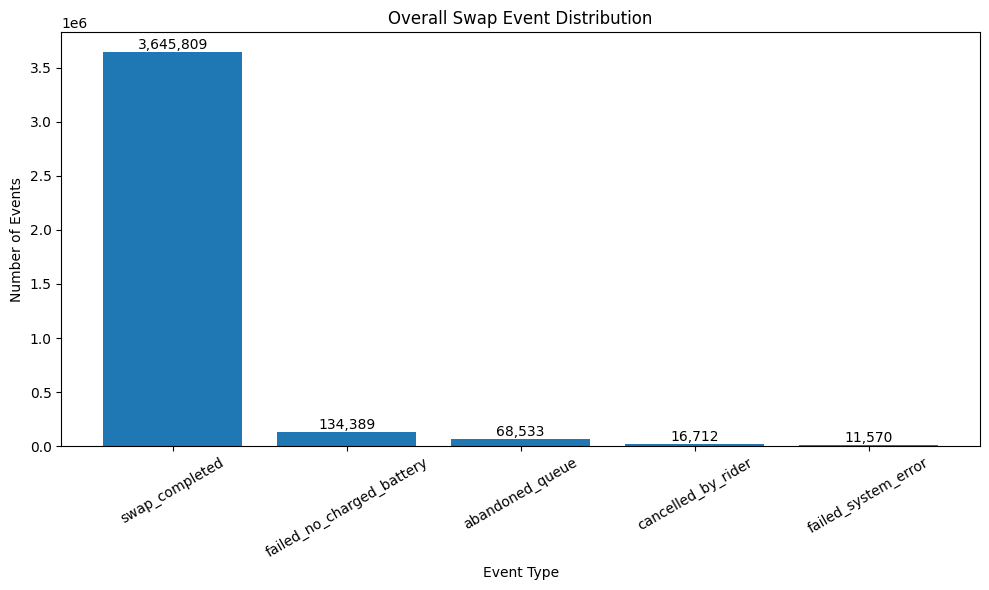

In [ ]:
# Event counts
event_summary = (
    df["event_type"]
    .value_counts()
    .reset_index()
)

event_summary.columns = ["event_type", "count"]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    event_summary["event_type"],
    event_summary["count"]
)

plt.title("Overall Swap Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=30)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Detected date column: event_ts


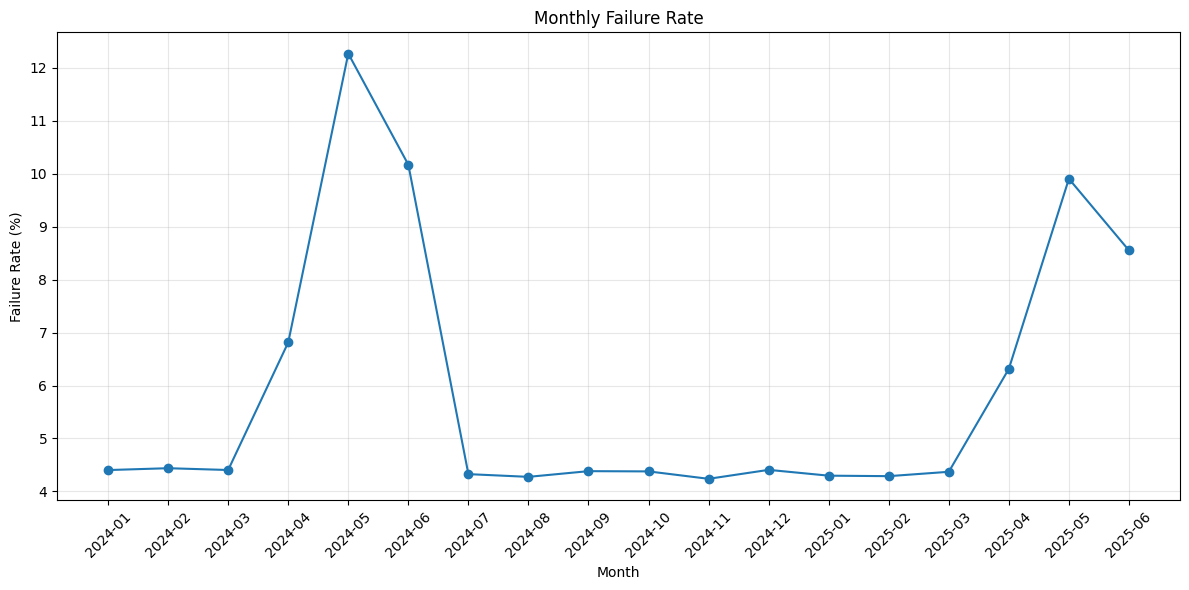

In [ ]:
# Convert timestamp
date_col = "event_ts"

# The original loop failed to find the 'event_ts' column because its condition was too restrictive.
# for col in df.columns:
#     if "date" in col.lower() or "time" in col.lower() or "timestamp" in col.lower():
#         date_col = col
#         break

print("Detected date column:", date_col)

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

df["month"] = df[date_col].dt.to_period("M").astype(str)

# Total attempts
monthly_total = df.groupby("month").size()

# Failed events
failure_types = [
    "failed_no_charged_battery",
    "failed_system_error",
    "abandoned_queue",
    "cancelled_by_rider"
]

monthly_failures = (
    df[df["event_type"].isin(failure_types)]
    .groupby("month")
    .size()
)

monthly_failure_rate = (
    monthly_failures / monthly_total * 100
).fillna(0)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_failure_rate.index,
    monthly_failure_rate.values,
    marker="o"
)

plt.title("Monthly Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

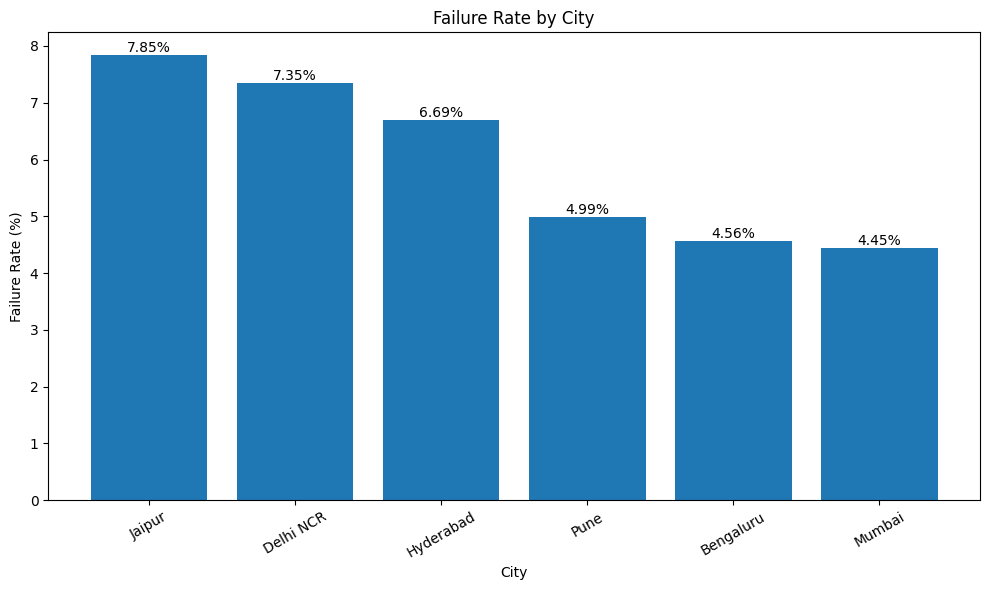

In [ ]:
city_chart = city_kpis.copy()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    city_chart["city"],
    city_chart["failure_rate"]
)

plt.title("Failure Rate by City")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

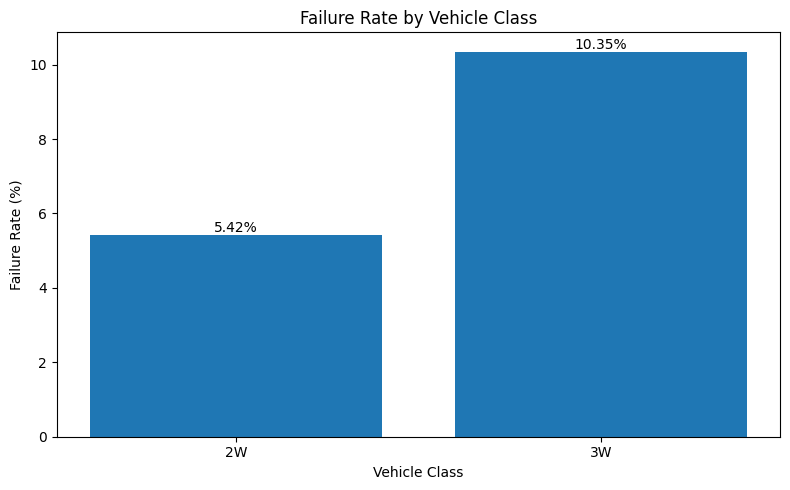

In [ ]:
vehicle_chart = vehicle_kpis.copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    vehicle_chart["vehicle_class"],
    vehicle_chart["failure_rate"]
)

plt.title("Failure Rate by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Failure Rate (%)")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

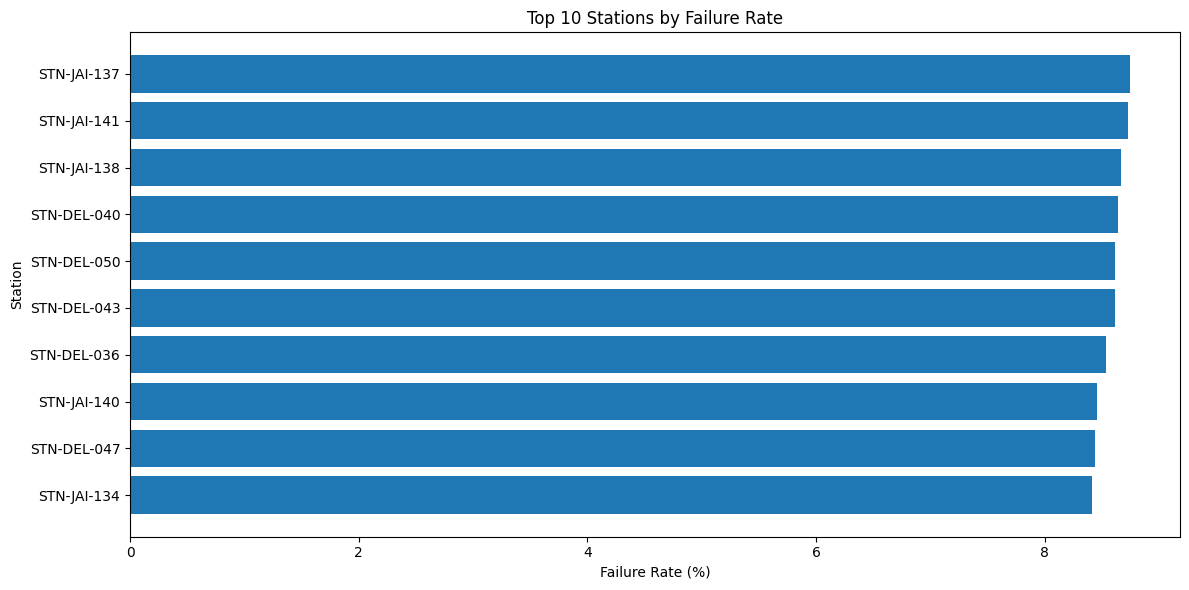

In [ ]:
station_chart = priority_stations.copy()

station_chart = (
    station_chart
    .sort_values("failure_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    station_chart["station_id"],
    station_chart["failure_rate"]
)

plt.title("Top 10 Stations by Failure Rate")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

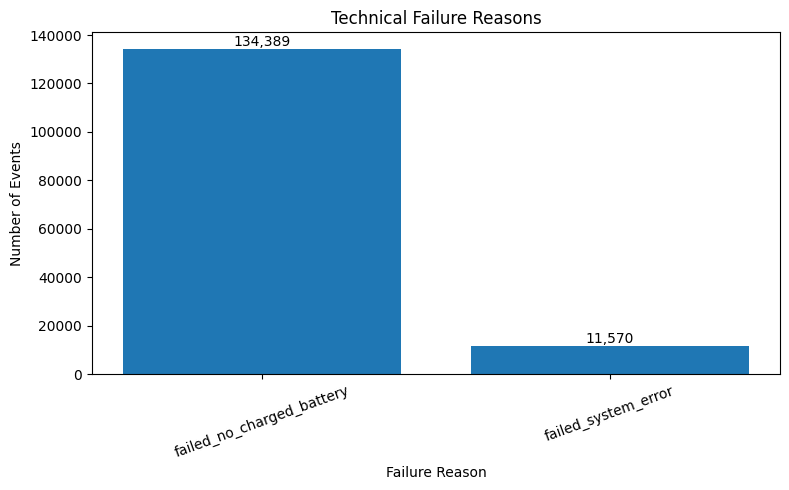

In [ ]:
technical_failures = event_counts_df[
    event_counts_df["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ])
].copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    technical_failures["event_type"],
    technical_failures["count"]
)

plt.title("Technical Failure Reasons")
plt.xlabel("Failure Reason")
plt.ylabel("Number of Events")
plt.xticks(rotation=20)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
battery_failure = 134389
system_failure = 11570

battery_percentage = (
    battery_failure /
    (battery_failure + system_failure)
) * 100

print(f"Battery-related technical failures: {battery_percentage:.2f}%")

Battery-related technical failures: 92.07%


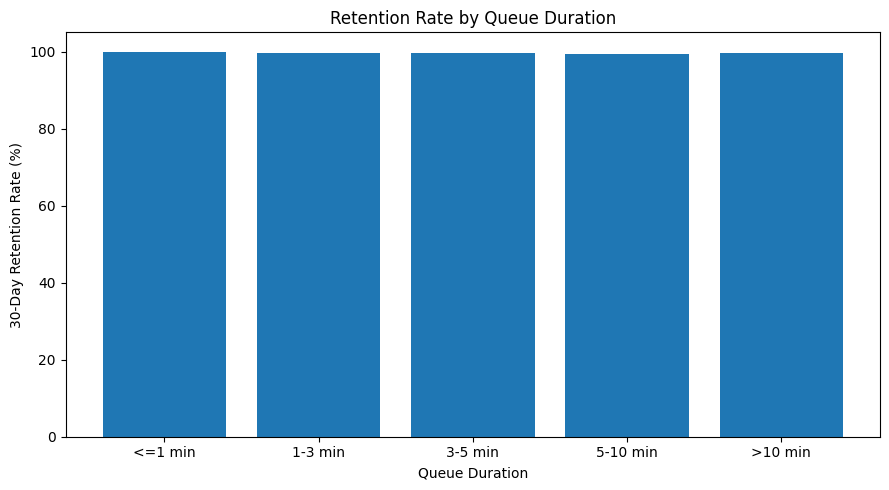

In [ ]:
queue_chart = queue_retention.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    queue_chart["queue_bucket"],
    queue_chart["retention_rate_pct"]
)

plt.title("Retention Rate by Queue Duration")
plt.xlabel("Queue Duration")
plt.ylabel("30-Day Retention Rate (%)")

plt.tight_layout()
plt.show()

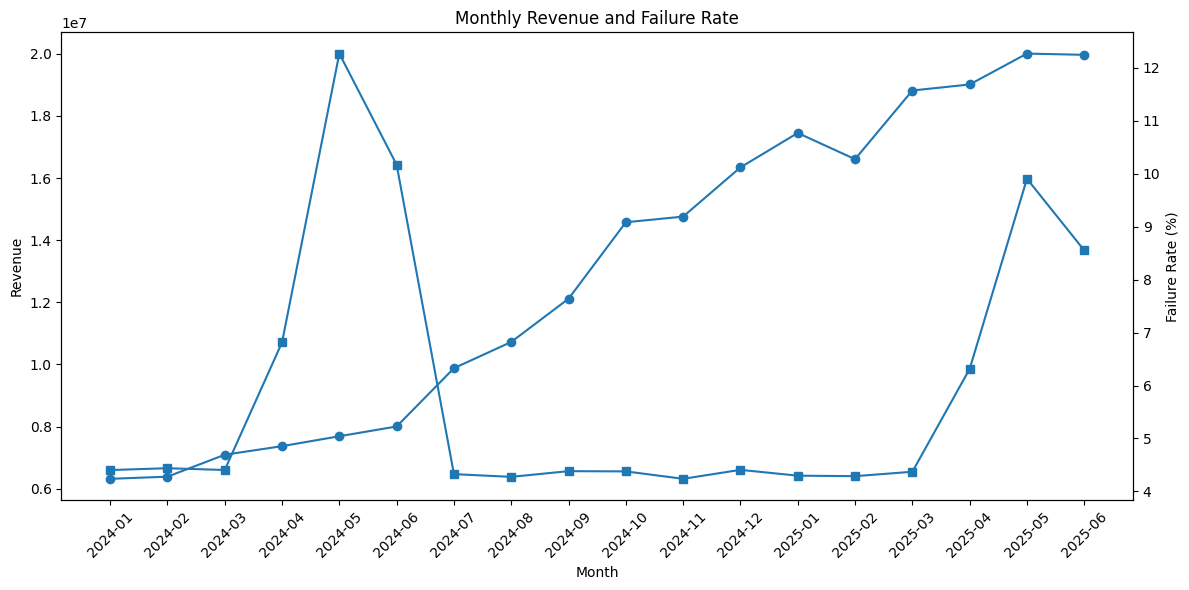

In [ ]:
monthly_chart = monthly_kpis.copy()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_chart["month"],
    monthly_chart["revenue"],
    marker="o"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")

ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_chart["month"],
    monthly_chart["failure_rate"],
    marker="s"
)

ax2.set_ylabel("Failure Rate (%)")

plt.title("Monthly Revenue and Failure Rate")

plt.tight_layout()
plt.show()